# EDA Advan (mobility) data

This notebook contains several EDA plots for the advan mobility data.

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import glob

import seaborn as sns
from cgnn.process_xwalk import get_county_cbsa_map

## New EDA Advan data
This section performs EDA on the newly processed Advan data that accounts for POIs with shared Polygons (e.g., multiple stores in a mall that share the same geometry). For shared POIs, there is a primary POI. I filter out all other POIs.

In [2]:
# combine advan data
in_dir = '../../data/raw/mobility/advan'
df = pd.concat([pd.read_csv(f"{in_dir}/2020_fix_advan.csv", dtype={"cbsa_orig": str, "cbsa_dest": str})] + [pd.read_csv(f"{in_dir}/{y}_advan.csv", dtype={"cbsa_orig": str, "cbsa_dest": str}) for y in range(2021, 2026)])
df.head()


,date_range_start,date_range_end,cbsa_orig,cbsa_dest,visitor_home_aggregation
0,2020-01-06,2020-01-13,10100,10100,84634
1,2020-01-06,2020-01-13,10100,10660,20
2,2020-01-06,2020-01-13,10100,10820,8
3,2020-01-06,2020-01-13,10100,13900,289
4,2020-01-06,2020-01-13,10100,14500,12


In [ ]:
# df.to_csv('../../data/raw/mobility/advan/all_advan_filter_shared_pois.csv', index=False)

In [ ]:
# df.head()

,date_range_start,date_range_end,cbsa_orig,cbsa_dest,visitor_home_aggregation
0,2020-01-06,2020-01-13,10100,10100,84634
1,2020-01-06,2020-01-13,10100,10660,20
2,2020-01-06,2020-01-13,10100,10820,8
3,2020-01-06,2020-01-13,10100,13900,289
4,2020-01-06,2020-01-13,10100,14500,12


In [4]:
%%time
advan_df = df.copy()
# advan_df = pd.read_csv('../../data/raw/mobility/advan/all_advan_filter_shared_pois.csv', dtype={"cbsa_orig": str, "cbsa_dest": str})
safegraph_df = pd.read_csv('../../data/raw/mobility/safegraph/all_harddrive_us.csv', dtype={"cbsa_orig": str, "cbsa_dest": str})

CPU times: user 22.5 s, sys: 22.1 s, total: 44.6 s
Wall time: 45.4 s


In [5]:
advan_old_df = pd.read_csv('../../data/raw/mobility/advan/all_advan_fix.csv', dtype={"cbsa_orig": str, "cbsa_dest": str})

In [6]:
advan_scatter_df = advan_old_df.merge(advan_df, on=["cbsa_orig", "cbsa_dest", "date_range_start", "date_range_end"], how="inner", suffixes=("_old", "_new"))
advan_scatter_df.head()

,cbsa_orig,cbsa_dest,date_range_start,date_range_end,visitor_home_aggregation_old,visitor_home_aggregation_new
0,10100,10100,2020-01-06,2020-01-13,151812,84634
1,10100,10100,2020-01-13,2020-01-20,131991,73183
2,10100,10100,2020-01-20,2020-01-27,147445,82851
3,10100,10100,2020-01-27,2020-02-03,140151,79334
4,10100,10100,2020-02-03,2020-02-10,155653,87499


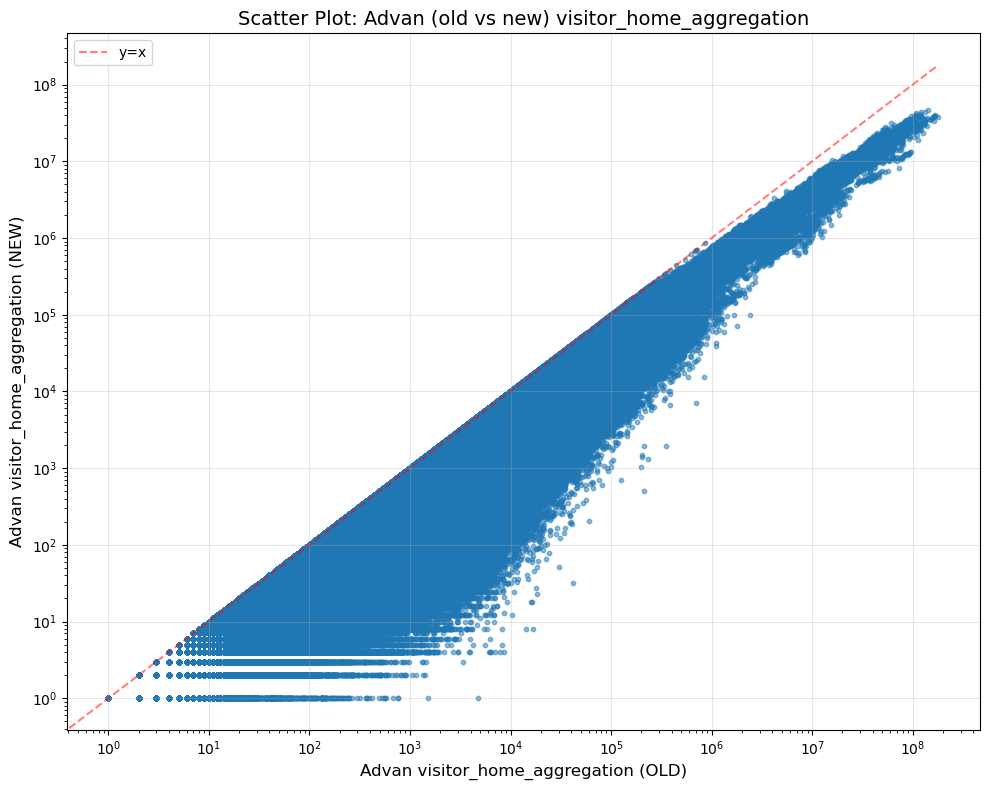


Correlation: 0.9718


In [18]:
plt.figure(figsize=(10, 8))

advan_scatter_df["date_range_start"] = pd.to_datetime(advan_scatter_df["date_range_start"])

plt.scatter(
    advan_scatter_df['visitor_home_aggregation_old'],
    advan_scatter_df['visitor_home_aggregation_new'],
    alpha=0.5,
    s=10,
)

plt.xlabel('Advan visitor_home_aggregation', fontsize=12)
plt.ylabel('Safegraph visitor_home_aggregation', fontsize=12)
plt.title('Scatter Plot: Advan (old vs new) visitor_home_aggregation', fontsize=14)
plt.grid(True, alpha=0.3)

# Add diagonal line for reference
max_val = max(
    advan_scatter_df['visitor_home_aggregation_old'].max(),
    advan_scatter_df['visitor_home_aggregation_new'].max()
)
min_val = min(
    advan_scatter_df['visitor_home_aggregation_old'].min(),
    advan_scatter_df['visitor_home_aggregation_new'].min()
)
plt.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5, label='y=x')
plt.legend()

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Advan visitor_home_aggregation (OLD)', fontsize=12)
plt.ylabel('Advan visitor_home_aggregation (NEW)', fontsize=12)

plt.tight_layout()
plt.show()

# Print correlation
correlation = advan_scatter_df['visitor_home_aggregation_old'].corr(
    advan_scatter_df['visitor_home_aggregation_new']
)
print(f"\nCorrelation: {correlation:.4f}")

In [13]:
advan_scatter_df[advan_scatter_df["visitor_home_aggregation_old"] == advan_scatter_df["visitor_home_aggregation_new"]].shape

(17485373, 7)

In [17]:
advan_scatter_df[advan_scatter_df["visitor_home_aggregation_old"] < advan_scatter_df["visitor_home_aggregation_new"]].shape

(0, 7)

In [30]:
advan_scatter_df.loc[advan_scatter_df['ratio'].notna() & np.isfinite(advan_scatter_df['ratio']), 'ratio'].mean()

1.8987021005199716

In [8]:
%%time
# Convert date columns to YYYY-MM-DD strings for consistent merging
advan_df['date_range_start'] = pd.to_datetime(advan_df['date_range_start']).dt.strftime('%Y-%m-%d')
advan_df['date_range_end'] = pd.to_datetime(advan_df['date_range_end']).dt.strftime('%Y-%m-%d')
safegraph_df['date_range_start'] = pd.to_datetime(safegraph_df['date_range_start']).dt.strftime('%Y-%m-%d')
safegraph_df['date_range_end'] = pd.to_datetime(safegraph_df['date_range_end']).dt.strftime('%Y-%m-%d')

# Ensure cbsa columns are strings for consistent merging
advan_df['cbsa_orig'] = advan_df['cbsa_orig'].astype(str)
advan_df['cbsa_dest'] = advan_df['cbsa_dest'].astype(str)
safegraph_df['cbsa_orig'] = safegraph_df['cbsa_orig'].astype(str)
safegraph_df['cbsa_dest'] = safegraph_df['cbsa_dest'].astype(str)

# Merge on the specified columns
merged_df = advan_df.merge(
    safegraph_df,
    on=['date_range_start', 'date_range_end', 'cbsa_orig', 'cbsa_dest'],
    suffixes=('_advan', '_safegraph'),
    how='inner'
)

print(f"\nMerged dataframe shape: {merged_df.shape}")
print(f"Number of matching records: {len(merged_df)}")


Merged dataframe shape: (13847623, 13)
Number of matching records: 13847623
CPU times: user 2min 5s, sys: 45.8 s, total: 2min 51s
Wall time: 3min 20s


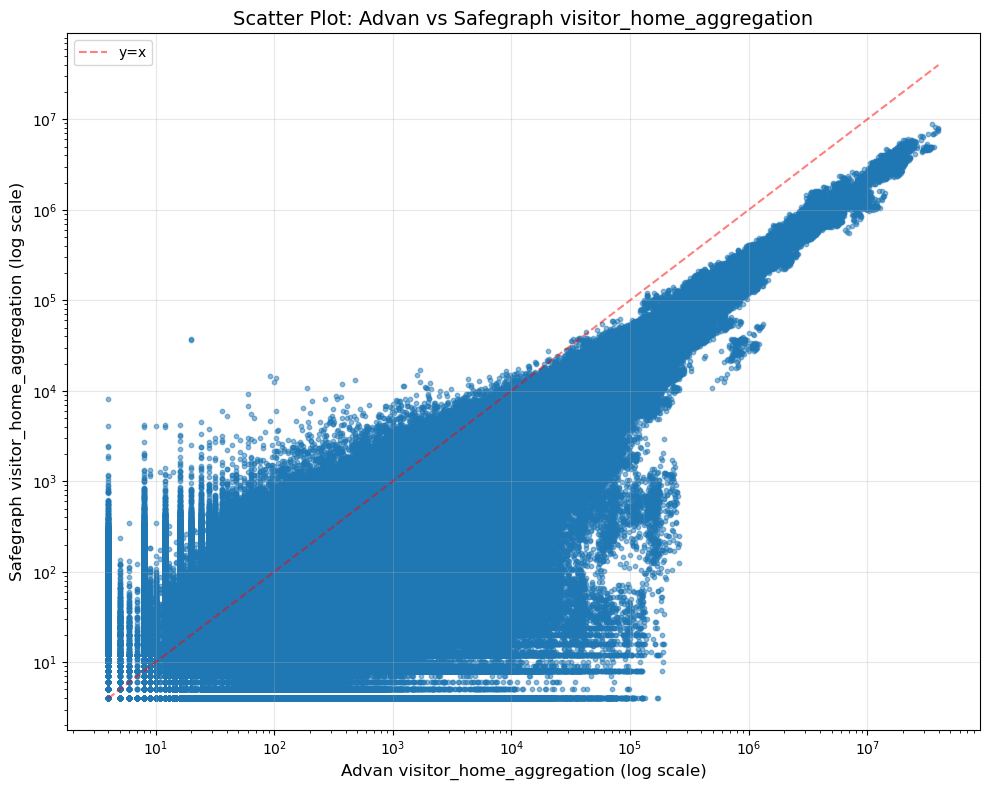


Correlation: 0.9730
CPU times: user 1min 36s, sys: 8.73 s, total: 1min 45s
Wall time: 1min 43s


In [10]:
%%time
plt.figure(figsize=(10, 8))

merged_df["date_range_start"] = pd.to_datetime(merged_df["date_range_start"])


plt.scatter(
    merged_df['visitor_home_aggregation_advan'],
    merged_df['visitor_home_aggregation_safegraph'],
    alpha=0.5,
    s=10,
)
plt.xlabel('Advan visitor_home_aggregation', fontsize=12)
plt.ylabel('Safegraph visitor_home_aggregation', fontsize=12)
plt.title('Scatter Plot: Advan vs Safegraph visitor_home_aggregation', fontsize=14)
plt.grid(True, alpha=0.3)

# Add diagonal line for reference
max_val = max(
    merged_df['visitor_home_aggregation_advan'].max(),
    merged_df['visitor_home_aggregation_safegraph'].max()
)
min_val = min(
    merged_df['visitor_home_aggregation_advan'].min(),
    merged_df['visitor_home_aggregation_safegraph'].min()
)
plt.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5, label='y=x')
plt.legend()

# Use log scale if data spans large range
if max_val / min_val > 100:
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Advan visitor_home_aggregation (log scale)', fontsize=12)
    plt.ylabel('Safegraph visitor_home_aggregation (log scale)', fontsize=12)

plt.tight_layout()
plt.show()

# Print correlation
correlation = merged_df['visitor_home_aggregation_advan'].corr(
    merged_df['visitor_home_aggregation_safegraph']
)
print(f"\nCorrelation: {correlation:.4f}")


## Old EDA Advan Data

In [55]:
%%time
advan_df = pd.read_csv('../../data/raw/mobility/advan/all_advan_fix.csv', dtype={"cbsa_orig": str, "cbsa_dest": str})
safegraph_df = pd.read_csv('../../data/raw/mobility/safegraph/all_harddrive_us.csv', dtype={"cbsa_orig": str, "cbsa_dest": str})


CPU times: user 39.7 s, sys: 22.9 s, total: 1min 2s
Wall time: 1min 49s


## 1. Safegraph vs Advan Scatter plot

In [56]:
print(advan_df.date_range_end.max())
print(safegraph_df.date_range_end.max())

2025-06-30
2023-01-02


Check that both are unique by cbsa X date

In [57]:
print(advan_df.shape)
print(safegraph_df.shape)

(44490446, 5)
(26485695, 12)


In [58]:
print(advan_df.shape)
advan_df.drop_duplicates(subset=["cbsa_orig", "cbsa_dest", "date_range_start", "date_range_end"]).shape

(44490446, 5)


(44490446, 5)

In [59]:
%%time
# Convert date columns to YYYY-MM-DD strings for consistent merging
advan_df['date_range_start'] = pd.to_datetime(advan_df['date_range_start']).dt.strftime('%Y-%m-%d')
advan_df['date_range_end'] = pd.to_datetime(advan_df['date_range_end']).dt.strftime('%Y-%m-%d')
safegraph_df['date_range_start'] = pd.to_datetime(safegraph_df['date_range_start']).dt.strftime('%Y-%m-%d')
safegraph_df['date_range_end'] = pd.to_datetime(safegraph_df['date_range_end']).dt.strftime('%Y-%m-%d')

# Ensure cbsa columns are strings for consistent merging
advan_df['cbsa_orig'] = advan_df['cbsa_orig'].astype(str)
advan_df['cbsa_dest'] = advan_df['cbsa_dest'].astype(str)
safegraph_df['cbsa_orig'] = safegraph_df['cbsa_orig'].astype(str)
safegraph_df['cbsa_dest'] = safegraph_df['cbsa_dest'].astype(str)

# Merge on the specified columns
merged_df = advan_df.merge(
    safegraph_df,
    on=['date_range_start', 'date_range_end', 'cbsa_orig', 'cbsa_dest'],
    suffixes=('_advan', '_safegraph'),
    how='inner'
)

print(f"\nMerged dataframe shape: {merged_df.shape}")
print(f"Number of matching records: {len(merged_df)}")


Merged dataframe shape: (13941562, 13)
Number of matching records: 13941562
CPU times: user 2min 8s, sys: 54.3 s, total: 3min 3s
Wall time: 3min 22s


In [60]:
merged_df.date_range_end.nunique()

156

In [61]:
print(merged_df.cbsa_orig.nunique(), merged_df.cbsa_dest.nunique())

918 927


In [62]:
print(merged_df["date_range_start"].min())
print(merged_df["date_range_start"].max())
print(merged_df["date_range_start"].nunique())

2020-01-06
2022-12-26
156


In [63]:
merged_df_2022 = merged_df.loc[pd.to_datetime(merged_df["date_range_start"]).dt.year == 2022]

In [64]:
merged_df_2022.shape

(5234632, 13)

In [13]:
# Create scatter plot
def plot_scatter(merged_df, color_month=False):
    plt.figure(figsize=(10, 8))

    merged_df["date_range_start"] = pd.to_datetime(merged_df["date_range_start"])

    if color_month:
        for m in range(12):
            plt.scatter(
                merged_df.loc[merged_df["date_range_start"].dt.month == m, 'visitor_home_aggregation_advan'],
                merged_df.loc[merged_df["date_range_start"].dt.month == m, 'visitor_home_aggregation_safegraph'],
                alpha=0.5,
                s=10,
                label=m,
            )
    else:
        plt.scatter(
            merged_df['visitor_home_aggregation_advan'],
            merged_df['visitor_home_aggregation_safegraph'],
            alpha=0.5,
            s=10,
        )
    plt.xlabel('Advan visitor_home_aggregation', fontsize=12)
    plt.ylabel('Safegraph visitor_home_aggregation', fontsize=12)
    plt.title('Scatter Plot: Advan vs Safegraph visitor_home_aggregation', fontsize=14)
    plt.grid(True, alpha=0.3)
    
    # Add diagonal line for reference
    max_val = max(
        merged_df['visitor_home_aggregation_advan'].max(),
        merged_df['visitor_home_aggregation_safegraph'].max()
    )
    min_val = min(
        merged_df['visitor_home_aggregation_advan'].min(),
        merged_df['visitor_home_aggregation_safegraph'].min()
    )
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5, label='y=x')
    plt.legend()
    
    # Use log scale if data spans large range
    if max_val / min_val > 100:
        plt.xscale('log')
        plt.yscale('log')
        plt.xlabel('Advan visitor_home_aggregation (log scale)', fontsize=12)
        plt.ylabel('Safegraph visitor_home_aggregation (log scale)', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    # Print correlation
    correlation = merged_df['visitor_home_aggregation_advan'].corr(
        merged_df['visitor_home_aggregation_safegraph']
    )
    print(f"\nCorrelation: {correlation:.4f}")


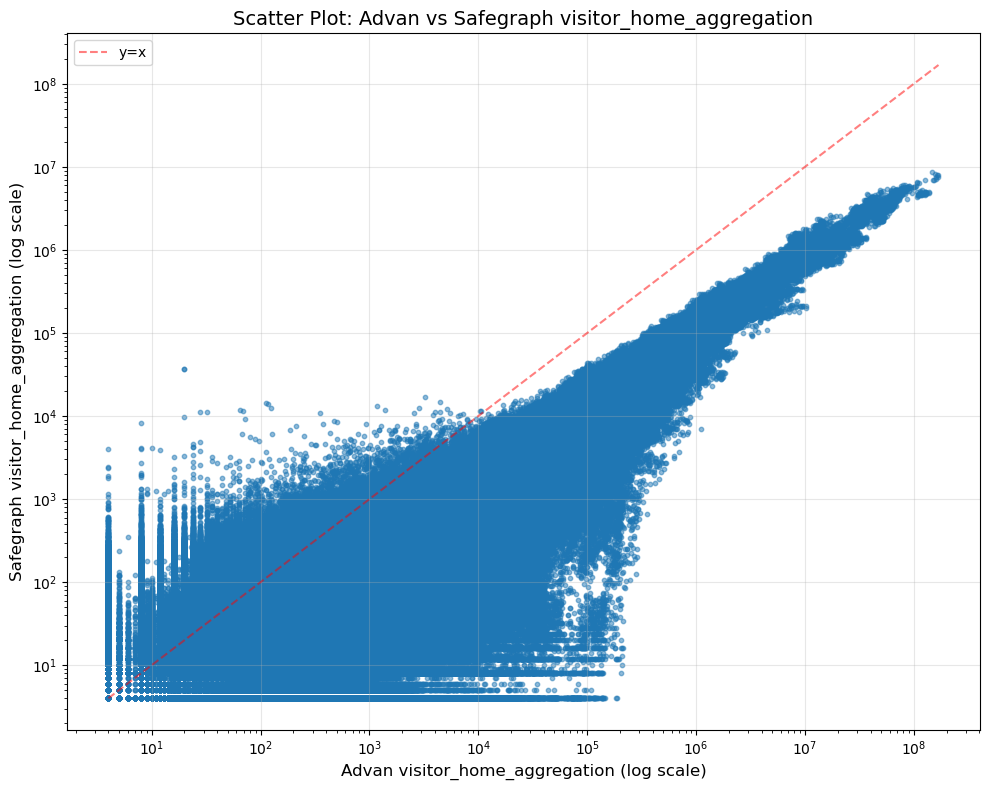


Correlation: 0.9530
CPU times: user 1min 37s, sys: 24.6 s, total: 2min 2s
Wall time: 2min 2s


In [13]:
%%time
plot_scatter(merged_df)

In [14]:
merged_df_2022["ratio"] = merged_df_2022["visitor_home_aggregation_advan"] / merged_df_2022["visitor_home_aggregation_safegraph"]

/local/ipykernel_1525408/1582435331.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df_2022["ratio"] = merged_df_2022["visitor_home_aggregation_advan"] / merged_df_2022["visitor_home_aggregation_safegraph"]


In [15]:
merged_df_2022["ratio"].describe()

count    5.234632e+06
mean     1.179921e+01
std      1.111881e+02
min      5.420936e-04
25%      1.954545e+00
50%      4.412698e+00
75%      1.000000e+01
max      4.703875e+04
Name: ratio, dtype: float64

In [16]:
merged_df_2022.loc[merged_df_2022["ratio"] > 100].groupby(["cbsa_orig", "cbsa_dest"])["date_range_start"].count().sort_values(ascending=False)

cbsa_orig  cbsa_dest
42660      28540        49
27140      35020        48
25420      44420        48
20700      30140        48
10900      44420        48
                        ..
26090      42660         1
           42340         1
           41860         1
           40900         1
26140      12020         1
Name: date_range_start, Length: 27007, dtype: int64

In [17]:
merged_df_2022.shape

(5234632, 14)

In [18]:
merged_df_2022.groupby(["cbsa_orig", "cbsa_dest", "date_range_start", "date_range_end"])[["visitor_home_aggregation_advan", "visitor_home_aggregation_safegraph"]].sum()

visitor_home_aggregation_advan  \
cbsa_orig cbsa_dest date_range_start date_range_end                                   
10100     10100     2022-01-03       2022-01-10                              137622   
                    2022-01-10       2022-01-17                              132718   
                    2022-01-17       2022-01-24                              130071   
                    2022-01-24       2022-01-31                              133348   
                    2022-01-31       2022-02-07                              140957   
...                                                                             ...   
49820     49820     2022-11-28       2022-12-05                               23327   
                    2022-12-05       2022-12-12                               22579   
                    2022-12-12       2022-12-19                               21826   
                    2022-12-19       2022-12-26                               19722   
                    2022-12-26       2023-01-02                               16608   

                                                     visitor_home_aggregation_safegraph  
cbsa_orig cbsa_dest date_range_start date_range_end                                      
10100     10100     2022-01-03       2022-01-10                                   12698  
                    2022-01-10       2022-01-17                                   13544  
                    2022-01-17       2022-01-24                                   12670  
                    2022-01-24       2022-01-31                                   13065  
                    2022-01-31       2022-02-07                                   13294  
...                                                                                 ...  
49820     49820     2022-11-28       2022-12-05                                    6017  
                    2022-12-05       2022-12-12                                    5952  
                    2022-12-12       2022-12-19                                    6122  
                    2022-12-19       2022-12-26                                    5950  
                    2022-12-26       2023-01-02                                    4439  

[5234632 rows x 2 columns]

In [19]:
merged_df_2022.groupby(["cbsa_orig", "cbsa_dest"])["date_range_start"].count().sort_values(ascending=False)

cbsa_orig  cbsa_dest
49820      29700        52
10100      13900        52
49820      49820        52
10100      10100        52
26090      27100        52
                        ..
49820      29180         1
           29380         1
           29740         1
           30420         1
           30980         1
Name: date_range_start, Length: 406875, dtype: int64

In [20]:
merged_df_2022.loc[merged_df_2022["ratio"] < 0.01].groupby(["cbsa_orig", "cbsa_dest"])["date_range_start"].count().sort_values(ascending=False)

cbsa_orig  cbsa_dest
14710      14710        6
40860      40860        5
28300      14710        4
26740      12060        3
21340      41620        3
41620      21340        2
15540      15540        2
47900      41980        2
10740      41620        1
21780      18020        1
16100      38060        1
30780      19740        1
25940      35620        1
17780      21340        1
33340      36420        1
37980      41980        1
36740      41980        1
41140      19740        1
45300      41980        1
Name: date_range_start, dtype: int64

In [ ]:
import seaborn as sns

# Define x and y for clarity
x_data = merged_df_2022['visitor_home_aggregation_advan']
y_data = merged_df_2022['visitor_home_aggregation_safegraph']

# Create density plot
plt.figure(figsize=(12, 8))

# *** Determine if log scale should be used, based on original logic ***
# Ensure min values are positive for log scale
min_x = max(min(x_data), 1e-1)
min_y = max(min(y_data), 1e-1)
use_log_scale = (x_data.max() / min_x > 100) or (y_data.max() / min_y > 100)

sns.kdeplot(
    x=x_data,
    y=y_data,
    fill=True,
    cmap='viridis',
    cbar=True,
    log_scale=use_log_scale
)

# *** Set labels, updating them if log scale was used ***
if use_log_scale:
    plt.xlabel('Advan visitor_home_aggregation (log scale)', fontsize=12)
    plt.ylabel('Safegraph visitor_home_aggregation (log scale)', fontsize=12)
else:
    plt.xlabel('Advan visitor_home_aggregation', fontsize=12)
    plt.ylabel('Safegraph visitor_home_aggregation', fontsize=12)

plt.title('KDE Plot: Advan vs Safegraph visitor_home_aggregation', fontsize=14)
plt.grid(True, alpha=0.3, linestyle=':')

# Add diagonal line for reference
# Ensure min_val is positive for log scale compatibility
min_val = max(
    min(x_data.min(), y_data.min()),
    1e-1  # Use a small positive number if min is zero or negative
)
max_val = max(
    x_data.max(),
    y_data.max()
)
plt.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.7, label='y=x')

# *** Set plot limits AFTER plotting, especially important for log scale ***
if use_log_scale:
    plt.xlim(min_val, max_val)
    plt.ylim(min_val, max_val)

plt.legend()  # Call legend after potential scale change to ensure it's placed well
plt.tight_layout()
plt.show()


plt.savefig('advan_vs_safegraph.png')


In [ ]:
# Enhanced scatter plots to investigate patterns in advan vs safegraph differences

def plot_scatter_by_time(merged_df, year=2022):
    """Scatter plot colored by month to check if outliers vary by time"""
    df = merged_df.loc[pd.to_datetime(merged_df["date_range_start"]).dt.year == year].copy()
    df["date_range_start"] = pd.to_datetime(df["date_range_start"])
    df["month"] = df["date_range_start"].dt.month
    
    plt.figure(figsize=(12, 10))
    
    scatter = plt.scatter(
        df['visitor_home_aggregation_advan'],
        df['visitor_home_aggregation_safegraph'],
        c=df['month'],
        cmap='tab20',
        alpha=0.6,
        s=20,
        edgecolors='black',
        linewidths=0.1
    )
    
    plt.colorbar(scatter, label='Month')
    plt.xlabel('Advan visitor_home_aggregation', fontsize=12)
    plt.ylabel('Safegraph visitor_home_aggregation', fontsize=12)
    plt.title(f'Scatter Plot by Month (Year {year}): Advan vs Safegraph', fontsize=14)
    plt.grid(True, alpha=0.3)
    
    # Add diagonal line
    max_val = max(
        df['visitor_home_aggregation_advan'].max(),
        df['visitor_home_aggregation_safegraph'].max()
    )
    min_val = max(
        min(df['visitor_home_aggregation_advan'].min(), df['visitor_home_aggregation_safegraph'].min()),
        1e-1
    )
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5, label='y=x')
    
    # Use log scale if needed
    if max_val / min_val > 100:
        plt.xscale('log')
        plt.yscale('log')
        plt.xlabel('Advan visitor_home_aggregation (log scale)', fontsize=12)
        plt.ylabel('Safegraph visitor_home_aggregation (log scale)', fontsize=12)
    
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Print correlation by month
    print("\nCorrelation by month:")
    for month in sorted(df['month'].unique()):
        month_df = df[df['month'] == month]
        corr = month_df['visitor_home_aggregation_advan'].corr(
            month_df['visitor_home_aggregation_safegraph']
        )
        print(f"  Month {int(month)}: {corr:.4f}")



In [ ]:
def plot_scatter_by_cbsa_pair(merged_df, year=2022, top_n=20):
    """Scatter plot highlighting top outlier cbsa_orig X cbsa_dest pairs"""
    df = merged_df.loc[pd.to_datetime(merged_df["date_range_start"]).dt.year == year].copy()
    df["date_range_start"] = pd.to_datetime(df["date_range_start"])
    df["ratio"] = df["visitor_home_aggregation_advan"] / df["visitor_home_aggregation_safegraph"]
    df["cbsa_pair"] = df["cbsa_orig"] + " -> " + df["cbsa_dest"]
    
    # Identify top outlier pairs (high and low ratios)
    high_ratio_pairs = df.loc[df["ratio"] > 100].groupby("cbsa_pair")["ratio"].count().sort_values(ascending=False).head(top_n).index
    low_ratio_pairs = df.loc[df["ratio"] < 0.01].groupby("cbsa_pair")["ratio"].count().sort_values(ascending=False).head(top_n).index
    
    plt.figure(figsize=(14, 10))
    
    # Plot all points in gray
    plt.scatter(
        df['visitor_home_aggregation_advan'],
        df['visitor_home_aggregation_safegraph'],
        c='lightgray',
        alpha=0.3,
        s=10,
        label='Other pairs'
    )
    
    # Highlight high ratio pairs (advan >> safegraph)
    if len(high_ratio_pairs) > 0:
        high_df = df[df["cbsa_pair"].isin(high_ratio_pairs)]
        plt.scatter(
            high_df['visitor_home_aggregation_advan'],
            high_df['visitor_home_aggregation_safegraph'],
            c='red',
            alpha=0.7,
            s=50,
            edgecolors='darkred',
            linewidths=0.5,
            label=f'High ratio pairs (ratio > 100, top {len(high_ratio_pairs)})'
        )
    
    # Highlight low ratio pairs (safegraph >> advan)
    if len(low_ratio_pairs) > 0:
        low_df = df[df["cbsa_pair"].isin(low_ratio_pairs)]
        plt.scatter(
            low_df['visitor_home_aggregation_advan'],
            low_df['visitor_home_aggregation_safegraph'],
            c='blue',
            alpha=0.7,
            s=50,
            edgecolors='darkblue',
            linewidths=0.5,
            label=f'Low ratio pairs (ratio < 0.01, top {len(low_ratio_pairs)})'
        )
    
    plt.xlabel('Advan visitor_home_aggregation', fontsize=12)
    plt.ylabel('Safegraph visitor_home_aggregation', fontsize=12)
    plt.title(f'Scatter Plot Highlighting Outlier CBSA Pairs (Year {year})', fontsize=14)
    plt.grid(True, alpha=0.3)
    
    # Add diagonal line
    max_val = max(
        df['visitor_home_aggregation_advan'].max(),
        df['visitor_home_aggregation_safegraph'].max()
    )
    min_val = max(
        min(df['visitor_home_aggregation_advan'].min(), df['visitor_home_aggregation_safegraph'].min()),
        1e-1
    )
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5, label='y=x')
    
    # Use log scale if needed
    if max_val / min_val > 100:
        plt.xscale('log')
        plt.yscale('log')
        plt.xlabel('Advan visitor_home_aggregation (log scale)', fontsize=12)
        plt.ylabel('Safegraph visitor_home_aggregation (log scale)', fontsize=12)
    
    plt.legend(loc='upper left', fontsize=10)
    plt.tight_layout()
    plt.show()
    
    # Print top outlier pairs
    print("\nTop high ratio pairs (advan >> safegraph):")
    for pair in high_ratio_pairs[:10]:
        pair_df = df[df["cbsa_pair"] == pair]
        print(f"  {pair}: {len(pair_df)} records, mean ratio: {pair_df['ratio'].mean():.2f}")
    
    print("\nTop low ratio pairs (safegraph >> advan):")
    for pair in low_ratio_pairs[:10]:
        pair_df = df[df["cbsa_pair"] == pair]
        print(f"  {pair}: {len(pair_df)} records, mean ratio: {pair_df['ratio'].mean():.4f}")



In [ ]:
def plot_ratio_heatmap_by_cbsa(merged_df, year=2022, top_n=30):
    """Heatmap showing ratio patterns by cbsa_orig X cbsa_dest"""
    df = merged_df.loc[pd.to_datetime(merged_df["date_range_start"]).dt.year == year].copy()
    df["ratio"] = df["visitor_home_aggregation_advan"] / df["visitor_home_aggregation_safegraph"]
    
    # Get top N most frequent cbsa pairs (by count of records)
    top_pairs = df.groupby(["cbsa_orig", "cbsa_dest"]).size().sort_values(ascending=False).head(top_n)
    top_orig = top_pairs.index.get_level_values(0).unique()[:top_n]
    top_dest = top_pairs.index.get_level_values(1).unique()[:top_n]
    
    # Create pivot table for heatmap
    pivot_data = df[df["cbsa_orig"].isin(top_orig) & df["cbsa_dest"].isin(top_dest)].groupby(
        ["cbsa_orig", "cbsa_dest"]
    )["ratio"].mean().reset_index()
    
    pivot_table = pivot_data.pivot(index="cbsa_orig", columns="cbsa_dest", values="ratio")
    
    plt.figure(figsize=(16, 12))
    sns.heatmap(
        pivot_table,
        cmap='RdYlBu_r',
        center=1.0,
        vmin=0.1,
        vmax=10,
        cbar_kws={'label': 'Mean Ratio (Advan/Safegraph)'},
        square=False,
        linewidths=0.1
    )
    plt.title(f'Heatmap: Mean Ratio by CBSA Origin X Destination (Year {year}, Top {top_n} pairs)', fontsize=14)
    plt.xlabel('CBSA Destination', fontsize=10)
    plt.ylabel('CBSA Origin', fontsize=10)
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    plt.show()



In [ ]:
def plot_ratio_distribution_by_dimension(merged_df, year=2022):
    """Plot ratio distributions across different dimensions"""
    df = merged_df.loc[pd.to_datetime(merged_df["date_range_start"]).dt.year == year].copy()
    df["date_range_start"] = pd.to_datetime(df["date_range_start"])
    df["ratio"] = df["visitor_home_aggregation_advan"] / df["visitor_home_aggregation_safegraph"]
    df["month"] = df["date_range_start"].dt.month
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Ratio distribution by month
    ax1 = axes[0, 0]
    for month in sorted(df['month'].unique()):
        month_data = df[df['month'] == month]['ratio']
        ax1.hist(month_data, bins=50, alpha=0.5, label=f'Month {int(month)}', density=True)
    ax1.set_xlabel('Ratio (Advan/Safegraph)', fontsize=10)
    ax1.set_ylabel('Density', fontsize=10)
    ax1.set_title('Ratio Distribution by Month', fontsize=12)
    ax1.set_xscale('log')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Box plot of ratio by month
    ax2 = axes[0, 1]
    df.boxplot(column='ratio', by='month', ax=ax2)
    ax2.set_xlabel('Month', fontsize=10)
    ax2.set_ylabel('Ratio (Advan/Safegraph, log scale)', fontsize=10)
    ax2.set_title('Ratio Distribution by Month (Box Plot)', fontsize=12)
    plt.suptitle('')  # Remove default title
    ax2.grid(True, alpha=0.3)
    
    # 3. Ratio vs absolute values (to see if outliers are in specific value ranges)
    ax3 = axes[1, 0]
    scatter = ax3.scatter(
        df['visitor_home_aggregation_advan'],
        df['ratio'],
        c=df['month'],
        cmap='tab20',
        alpha=0.5,
        s=10
    )
    ax3.set_xlabel('Advan visitor_home_aggregation', fontsize=10)
    ax3.set_ylabel('Ratio (Advan/Safegraph)', fontsize=10)
    ax3.set_title('Ratio vs Advan Value (colored by month)', fontsize=12)
    ax3.set_xscale('log')
    ax3.set_yscale('log')
    plt.colorbar(scatter, ax=ax3, label='Month')
    ax3.grid(True, alpha=0.3)
    
    # 4. Ratio vs absolute values (safegraph)
    ax4 = axes[1, 1]
    scatter = ax4.scatter(
        df['visitor_home_aggregation_safegraph'],
        df['ratio'],
        c=df['month'],
        cmap='tab20',
        alpha=0.5,
        s=10
    )
    ax4.set_xlabel('Safegraph visitor_home_aggregation', fontsize=10)
    ax4.set_ylabel('Ratio (Advan/Safegraph)', fontsize=10)
    ax4.set_title('Ratio vs Safegraph Value (colored by month)', fontsize=12)
    ax4.set_xscale('log')
    ax4.set_yscale('log')
    plt.colorbar(scatter, ax=ax4, label='Month')
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\nRatio statistics by month:")
    print(df.groupby('month')['ratio'].describe())



In [ ]:
def plot_outlier_analysis(merged_df, year=2022):
    """Comprehensive analysis of outliers with multiple visualizations"""
    df = merged_df.loc[pd.to_datetime(merged_df["date_range_start"]).dt.year == year].copy()
    df["date_range_start"] = pd.to_datetime(df["date_range_start"])
    df["ratio"] = df["visitor_home_aggregation_advan"] / df["visitor_home_aggregation_safegraph"]
    df["month"] = df["date_range_start"].dt.month
    df["cbsa_pair"] = df["cbsa_orig"] + " -> " + df["cbsa_dest"]
    
    # Define outliers
    df["is_high_outlier"] = df["ratio"] > 100
    df["is_low_outlier"] = df["ratio"] < 0.01
    
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    
    # 1. Outlier count by month
    ax1 = axes[0, 0]
    outlier_by_month = df.groupby('month').agg({
        'is_high_outlier': 'sum',
        'is_low_outlier': 'sum'
    })
    x = range(len(outlier_by_month))
    width = 0.35
    ax1.bar([i - width/2 for i in x], outlier_by_month['is_high_outlier'], width, 
            label='High outliers (ratio > 100)', color='red', alpha=0.7)
    ax1.bar([i + width/2 for i in x], outlier_by_month['is_low_outlier'], width,
            label='Low outliers (ratio < 0.01)', color='blue', alpha=0.7)
    ax1.set_xlabel('Month', fontsize=10)
    ax1.set_ylabel('Count of Outliers', fontsize=10)
    ax1.set_title('Outlier Count by Month', fontsize=12)
    ax1.set_xticks(x)
    ax1.set_xticklabels([int(m) for m in sorted(df['month'].unique())])
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')
    
    # 2. Top outlier cbsa pairs (high)
    ax2 = axes[0, 1]
    top_high_pairs = df[df['is_high_outlier']].groupby('cbsa_pair').size().sort_values(ascending=False).head(15)
    ax2.barh(range(len(top_high_pairs)), top_high_pairs.values)
    ax2.set_yticks(range(len(top_high_pairs)))
    ax2.set_yticklabels([pair[:40] + '...' if len(pair) > 40 else pair for pair in top_high_pairs.index], fontsize=8)
    ax2.set_xlabel('Count of High Outliers', fontsize=10)
    ax2.set_title('Top 15 CBSA Pairs with High Outliers (ratio > 100)', fontsize=12)
    ax2.grid(True, alpha=0.3, axis='x')
    
    # 3. Top outlier cbsa pairs (low)
    ax3 = axes[0, 2]
    top_low_pairs = df[df['is_low_outlier']].groupby('cbsa_pair').size().sort_values(ascending=False).head(15)
    ax3.barh(range(len(top_low_pairs)), top_low_pairs.values)
    ax3.set_yticks(range(len(top_low_pairs)))
    ax3.set_yticklabels([pair[:40] + '...' if len(pair) > 40 else pair for pair in top_low_pairs.index], fontsize=8)
    ax3.set_xlabel('Count of Low Outliers', fontsize=10)
    ax3.set_title('Top 15 CBSA Pairs with Low Outliers (ratio < 0.01)', fontsize=12)
    ax3.grid(True, alpha=0.3, axis='x')
    
    # 4. Scatter with outlier highlighting
    ax4 = axes[1, 0]
    # Normal points
    normal_df = df[~df['is_high_outlier'] & ~df['is_low_outlier']]
    ax4.scatter(normal_df['visitor_home_aggregation_advan'], 
                normal_df['visitor_home_aggregation_safegraph'],
                c='gray', alpha=0.3, s=5, label='Normal')
    # High outliers
    high_df = df[df['is_high_outlier']]
    if len(high_df) > 0:
        ax4.scatter(high_df['visitor_home_aggregation_advan'],
                    high_df['visitor_home_aggregation_safegraph'],
                    c='red', alpha=0.7, s=30, label=f'High outliers ({len(high_df)})')
    # Low outliers
    low_df = df[df['is_low_outlier']]
    if len(low_df) > 0:
        ax4.scatter(low_df['visitor_home_aggregation_advan'],
                    low_df['visitor_home_aggregation_safegraph'],
                    c='blue', alpha=0.7, s=30, label=f'Low outliers ({len(low_df)})')
    ax4.set_xlabel('Advan visitor_home_aggregation', fontsize=10)
    ax4.set_ylabel('Safegraph visitor_home_aggregation', fontsize=10)
    ax4.set_title('Scatter Plot with Outlier Highlighting', fontsize=12)
    ax4.set_xscale('log')
    ax4.set_yscale('log')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    # 5. Ratio distribution (log scale)
    ax5 = axes[1, 1]
    ax5.hist(df['ratio'], bins=1000, alpha=0.7, edgecolor='black')
    ax5.axvline(1.0, color='red', linestyle='--', linewidth=2, label='Ratio = 1')
    ax5.set_xlabel('Ratio (Advan/Safegraph)', fontsize=10)
    ax5.set_ylabel('Frequency', fontsize=10)
    ax5.set_title('Ratio Distribution (All Data)', fontsize=12)
    ax5.set_xscale('log')
    ax5.legend()
    ax5.grid(True, alpha=0.3, axis='y')
    
    # 6. Outlier percentage by cbsa_orig
    ax6 = axes[1, 2]
    top_orig = df['cbsa_orig'].value_counts().head(20).index
    orig_outlier_pct = df[df['cbsa_orig'].isin(top_orig)].groupby('cbsa_orig').apply(
        lambda x: (x['is_high_outlier'].sum() + x['is_low_outlier'].sum()) / len(x) * 100
    ).sort_values(ascending=False)
    ax6.barh(range(len(orig_outlier_pct)), orig_outlier_pct.values)
    ax6.set_yticks(range(len(orig_outlier_pct)))
    ax6.set_yticklabels([str(orig)[:30] + '...' if len(str(orig)) > 30 else str(orig) 
                         for orig in orig_outlier_pct.index], fontsize=8)
    ax6.set_xlabel('Outlier Percentage (%)', fontsize=10)
    ax6.set_title('Top 20 CBSA Origins by Outlier Percentage', fontsize=12)
    ax6.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"\nOutlier Summary (Year {year}):")
    print(f"  Total records: {len(df)}")
    print(f"  High outliers (ratio > 100): {df['is_high_outlier'].sum()} ({df['is_high_outlier'].sum()/len(df)*100:.2f}%)")
    print(f"  Low outliers (ratio < 0.01): {df['is_low_outlier'].sum()} ({df['is_low_outlier'].sum()/len(df)*100:.2f}%)")
    print(f"  Normal records: {(~df['is_high_outlier'] & ~df['is_low_outlier']).sum()}")



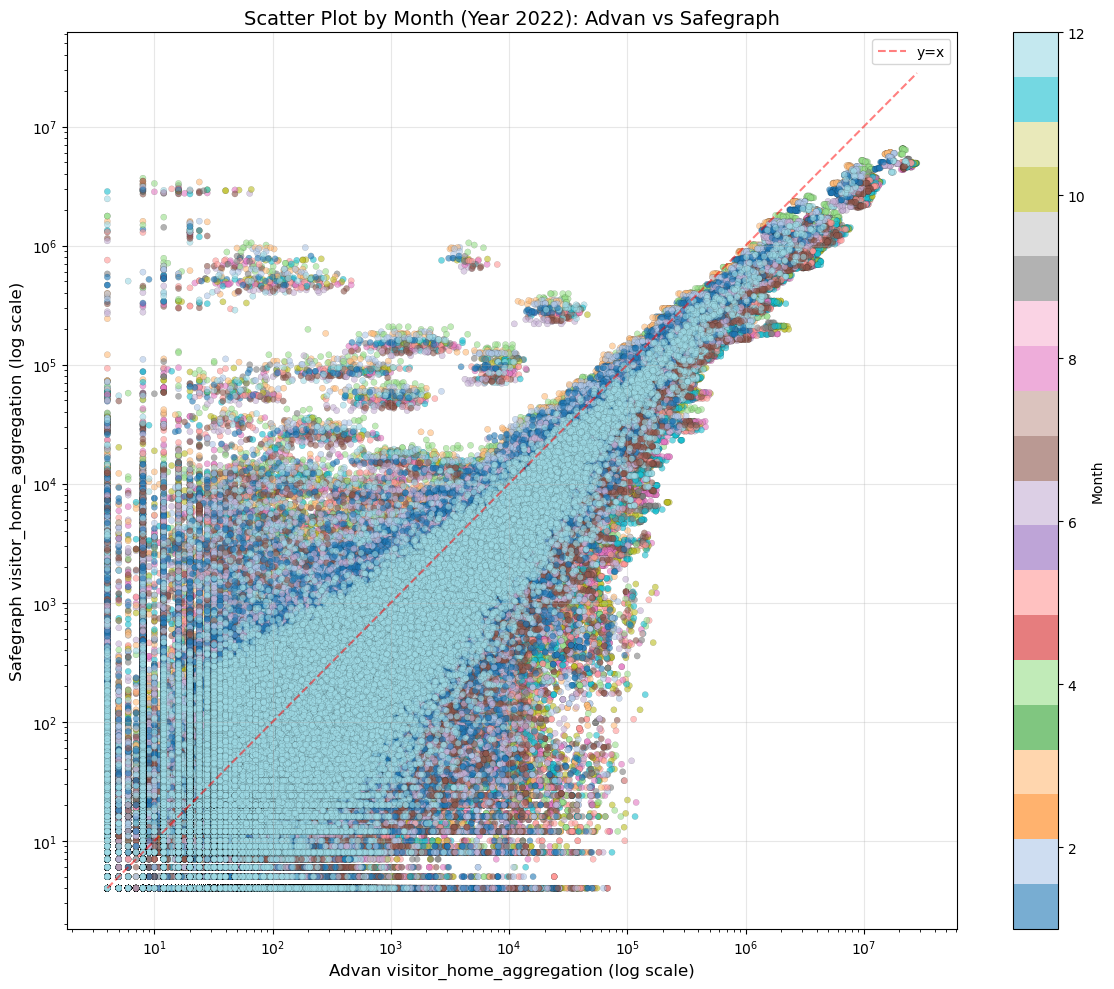


Correlation by month:
  Month 1: 0.9606
  Month 2: 0.9616
  Month 3: 0.9573
  Month 4: 0.9545
  Month 5: 0.9523
  Month 6: 0.9437
  Month 7: 0.9492
  Month 8: 0.9512
  Month 9: 0.9484
  Month 10: 0.9475
  Month 11: 0.9453
  Month 12: 0.9399
CPU times: user 6min 15s, sys: 56.7 s, total: 7min 11s
Wall time: 6min 54s


In [ ]:
%%time
# 1. Scatter plot colored by month to check time patterns
plot_scatter_by_time(merged_df_2022, year=2022)



In [ ]:
merged_df_2022['cbsa_orig'] = merged_df_2022['cbsa_orig'].astype(str)
merged_df_2022['cbsa_dest'] = merged_df_2022['cbsa_dest'].astype(str)

merged_df_2022.info()


/local/ipykernel_3000026/1192152220.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df_2022['cbsa_orig'] = merged_df_2022['cbsa_orig'].astype(str)
/local/ipykernel_3000026/1192152220.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df_2022['cbsa_dest'] = merged_df_2022['cbsa_dest'].astype(str)


<class 'pandas.core.frame.DataFrame'>
Index: 19943338 entries, 0 to 19943337
Data columns (total 14 columns):
 #   Column                              Dtype  
---  ------                              -----  
 0   date_range_start                    object 
 1   date_range_end                      object 
 2   cbsa_orig                           object 
 3   cbsa_dest                           object 
 4   visitor_home_aggregation_advan      int64  
 5   visitor_home_aggregation_safegraph  int64  
 6   VISITS_DAY_0                        int64  
 7   VISITS_DAY_1                        int64  
 8   VISITS_DAY_2                        int64  
 9   VISITS_DAY_3                        int64  
 10  VISITS_DAY_4                        int64  
 11  VISITS_DAY_5                        int64  
 12  VISITS_DAY_6                        int64  
 13  ratio                               float64
dtypes: float64(1), int64(9), object(4)
memory usage: 2.2+ GB


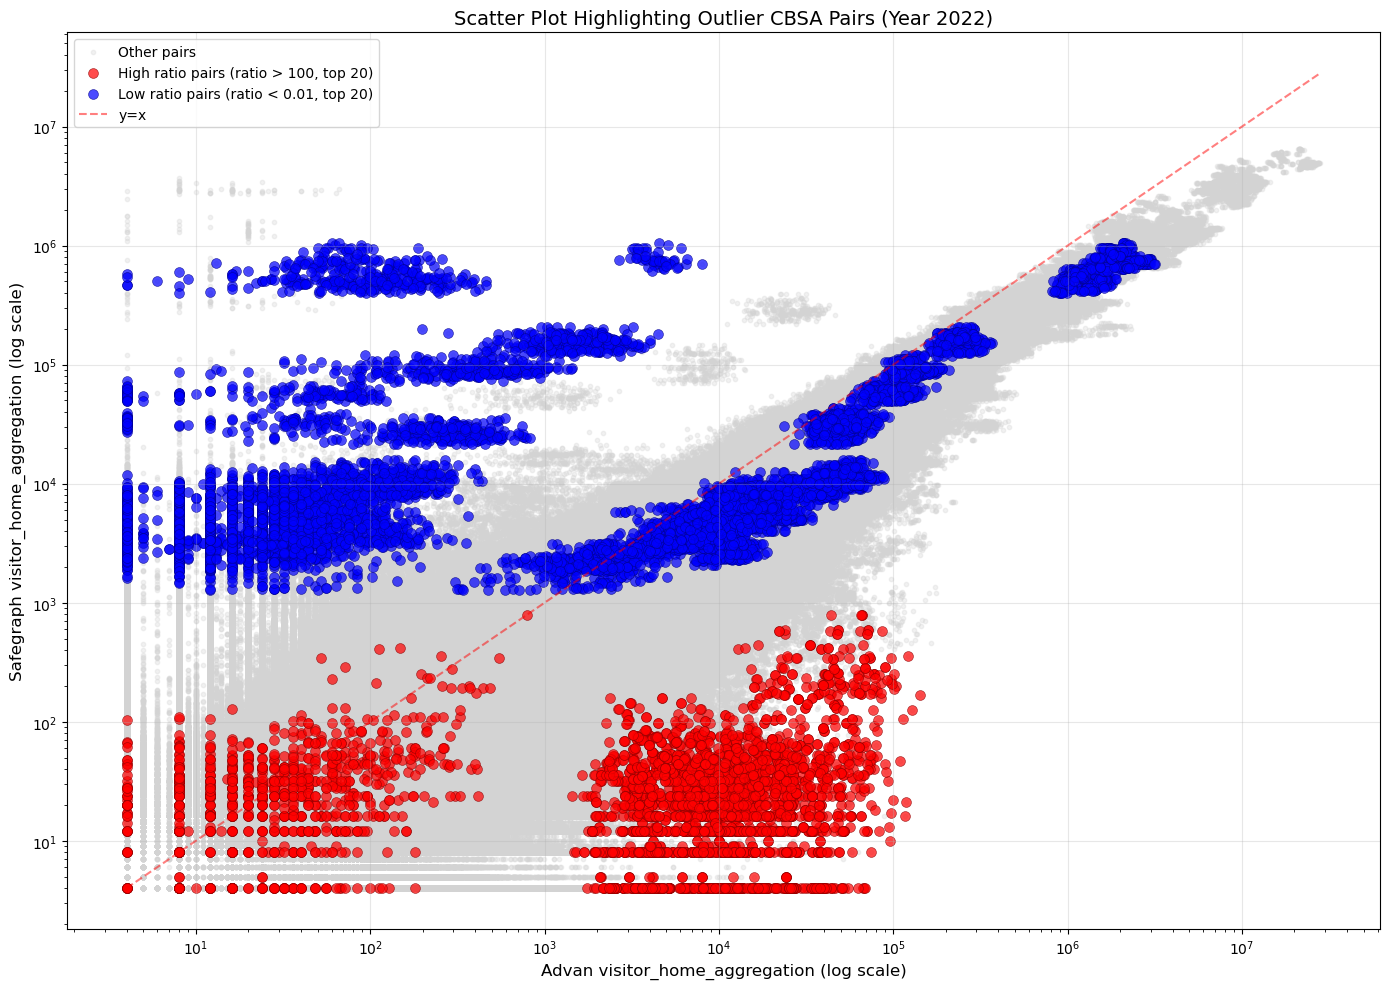


Top high ratio pairs (advan >> safegraph):
  31340 -> 14380: 237 records, mean ratio: 1002.98
  40220 -> 14380: 241 records, mean ratio: 2339.14
  11700 -> 40220: 254 records, mean ratio: 754.92
  48200 -> 14380: 223 records, mean ratio: 552.98
  11700 -> 14380: 260 records, mean ratio: 206.84
  13980 -> 14380: 229 records, mean ratio: 353.33
  35900 -> 40220: 187 records, mean ratio: 414.81
  25420 -> 27740: 153 records, mean ratio: 2833.92
  14380 -> 40220: 182 records, mean ratio: 655.06
  10900 -> 28700: 230 records, mean ratio: 503.33

Top low ratio pairs (safegraph >> advan):
  28940 -> 28940: 508 records, mean ratio: 1.3101
  43780 -> 43780: 519 records, mean ratio: 0.7488
  12060 -> 29300: 475 records, mean ratio: 1.1293
  10760 -> 12220: 519 records, mean ratio: 1.7362
  29300 -> 17980: 492 records, mean ratio: 2.3051
  12060 -> 17980: 421 records, mean ratio: 1.1166
  21060 -> 21060: 403 records, mean ratio: 1.1262
  19140 -> 16860: 516 records, mean ratio: 2.0225
  17980 ->

In [ ]:
%%time
# 2. Scatter plot highlighting top outlier CBSA pairs
plot_scatter_by_cbsa_pair(merged_df_2022, year=2022, top_n=20)



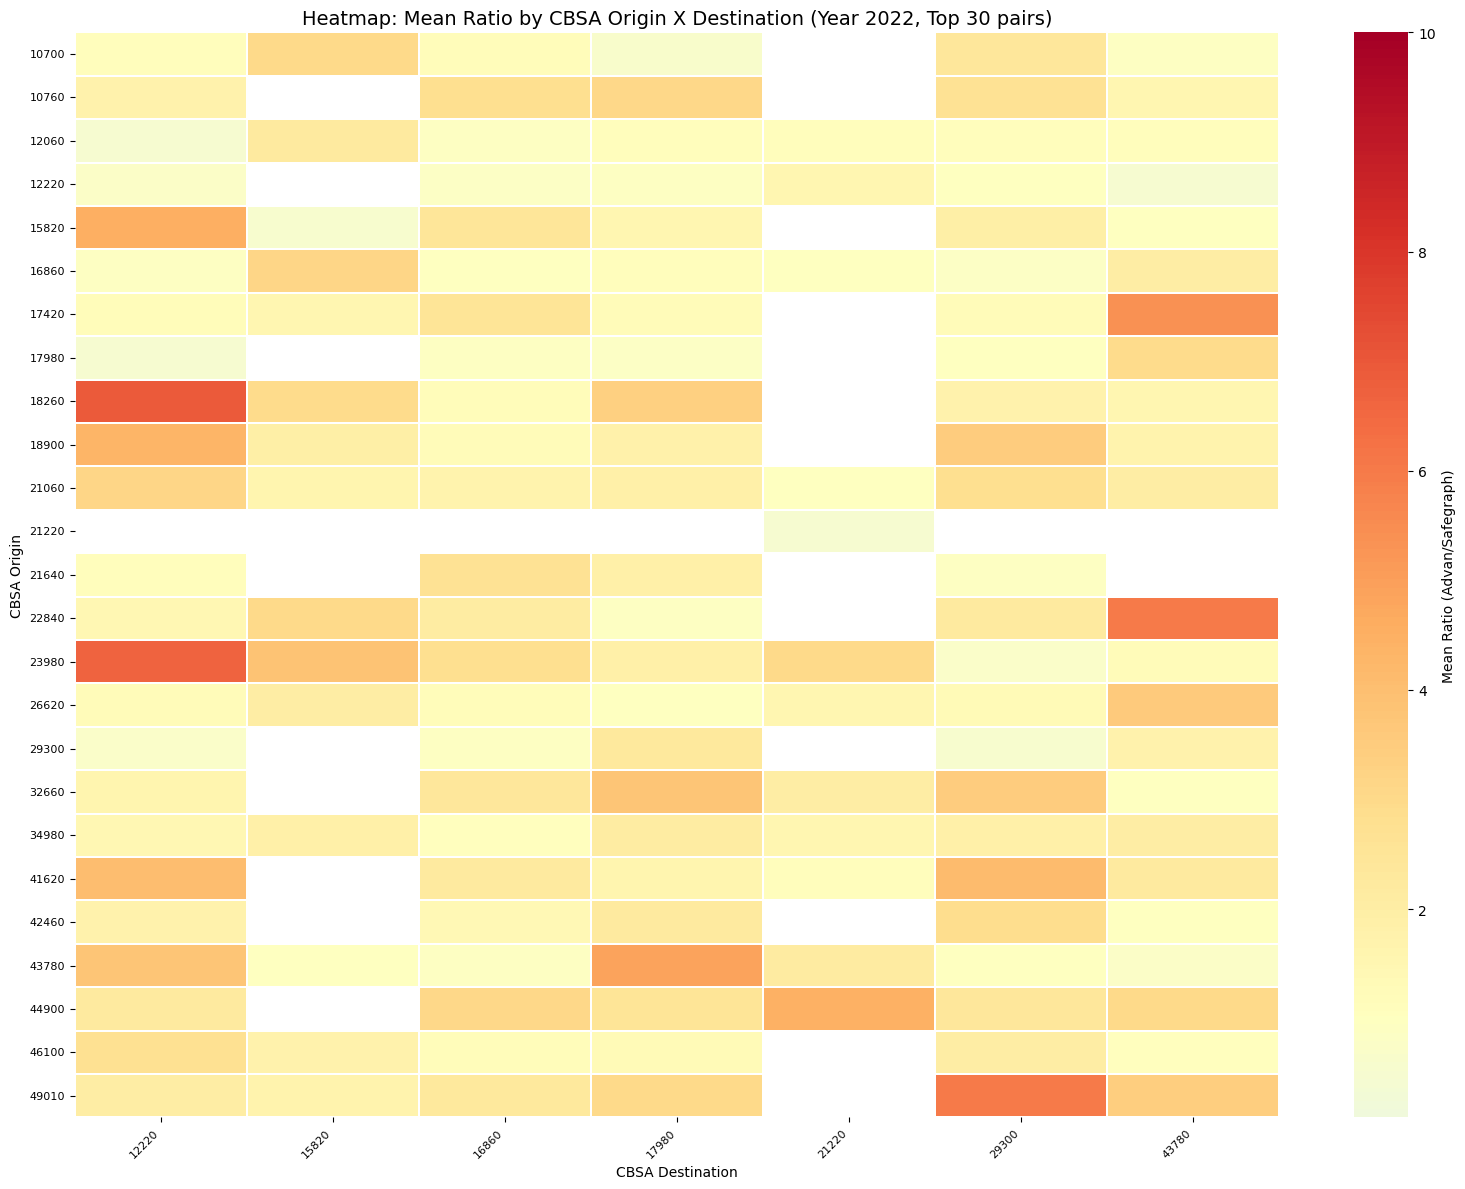

CPU times: user 10.7 s, sys: 16.2 s, total: 26.9 s
Wall time: 33 s


In [ ]:
%%time
# 3. Heatmap of ratios by CBSA origin X destination
plot_ratio_heatmap_by_cbsa(merged_df_2022, year=2022, top_n=30)



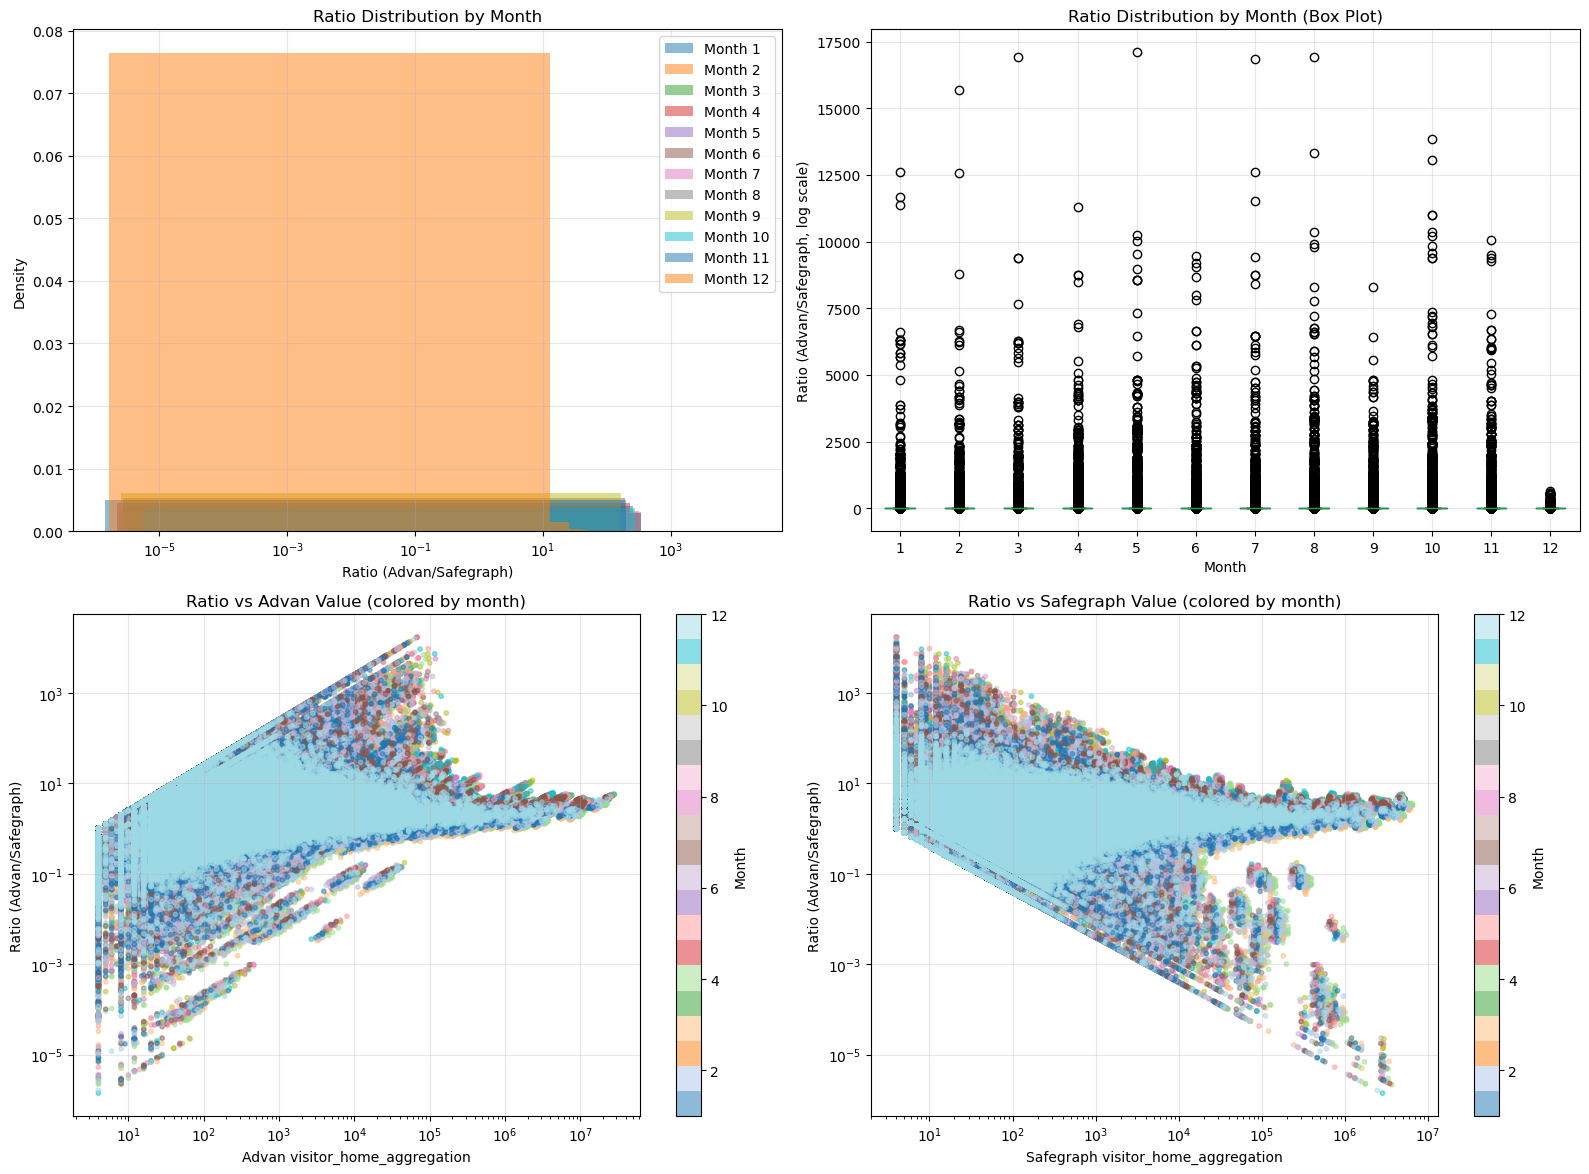


Ratio statistics by month:
           count      mean        std       min       25%       50%       75%  \
month                                                                           
1      1338640.0  2.827569  32.874625  0.000003  0.500000  1.020408  2.311041   
2      1183103.0  2.667887  35.660474  0.000003  0.486486  1.000000  2.142857   
3      1362080.0  2.357759  32.831979  0.000002  0.422524  0.963855  2.000000   
4      1475634.0  2.843357  32.440415  0.000002  0.500000  1.049180  2.292625   
5      2012490.0  3.323873  35.065977  0.000003  0.634146  1.345455  3.000000   
6      1776186.0  2.908646  31.150773  0.000003  0.558140  1.189392  2.545455   
7      2035644.0  3.246429  32.263239  0.000002  0.666667  1.400000  3.000000   
8      2222388.0  3.522893  34.710888  0.000004  0.666667  1.479182  3.000000   
9      1539053.0  3.264777  26.512412  0.000002  0.636364  1.349333  3.000000   
10     1923364.0  3.512252  39.644824  0.000006  0.666667  1.458333  3.000000   


In [ ]:
%%time
# 4. Ratio distributions across different dimensions
plot_ratio_distribution_by_dimension(merged_df_2022, year=2022)



/local/ipykernel_3000026/497327314.py:96: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  orig_outlier_pct = df[df['cbsa_orig'].isin(top_orig)].groupby('cbsa_orig').apply(
/local/ipykernel_3000026/497327314.py:107: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


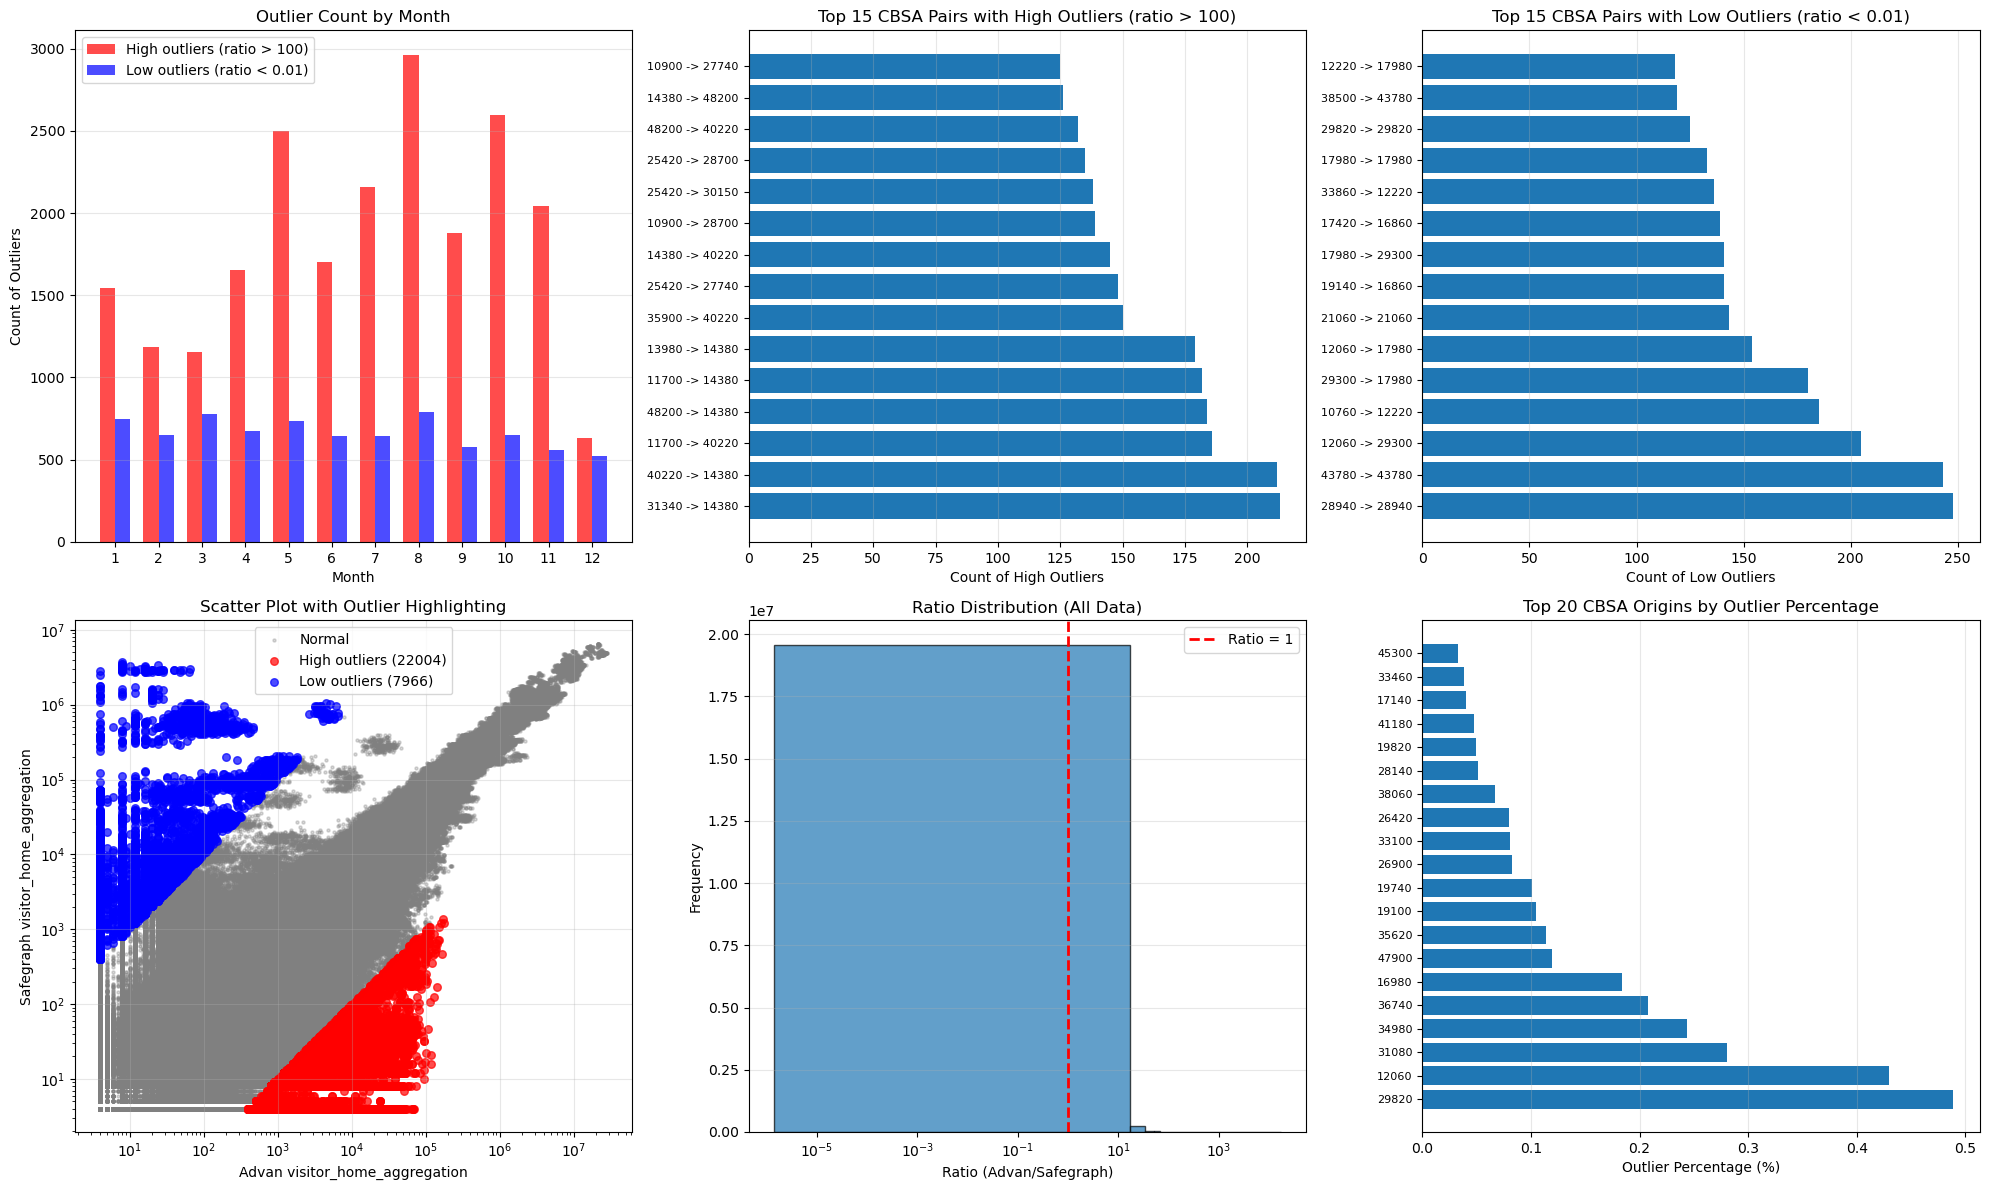


Outlier Summary (Year 2022):
  Total records: 19943338
  High outliers (ratio > 100): 22004 (0.11%)
  Low outliers (ratio < 0.01): 7966 (0.04%)
  Normal records: 19913368
CPU times: user 7min 17s, sys: 1min 54s, total: 9min 12s
Wall time: 9min 18s


In [ ]:
%%time
# 5. Comprehensive outlier analysis
plot_outlier_analysis(merged_df_2022, year=2022)


## 2. Investigation of High Ratio Cases (Advan >> SafeGraph)

This section focuses specifically on cases where Advan data is more than 100 times larger than SafeGraph data, as requested.


In [65]:
# Import CBSA mapping from utils
import sys
sys.path.append('../../src')
from cgnn.utils.codebook import TITLE_CBSA_MAP, HHS_REGION_MAP

# Create a proper copy of the full merged dataset
merged_df_clean = merged_df.copy()
merged_df_clean["ratio"] = merged_df_clean["visitor_home_aggregation_advan"] / merged_df_clean["visitor_home_aggregation_safegraph"]

# Filter for high ratio cases (Advan > 100x SafeGraph)
high_ratio_df = merged_df_clean[merged_df_clean["ratio"] > 100].copy()

print(f"Total records (all years): {len(merged_df_clean):,}")
print(f"High ratio records (>100x): {len(high_ratio_df):,}")
print(f"Percentage of high ratio records: {len(high_ratio_df)/len(merged_df_clean)*100:.3f}%")
print(f"Ratio range for high ratio cases: {high_ratio_df['ratio'].min():.1f} - {high_ratio_df['ratio'].max():.1f}")

# Add date information
high_ratio_df['date_range_start'] = pd.to_datetime(high_ratio_df['date_range_start'])
print(f"Date range: {high_ratio_df['date_range_start'].min()} to {high_ratio_df['date_range_start'].max()}")
print(f"Years covered: {sorted(high_ratio_df['date_range_start'].dt.year.unique())}")


Total records (all years): 13,941,562
High ratio records (>100x): 128,404
Percentage of high ratio records: 0.921%
Ratio range for high ratio cases: 100.0 - 47038.8
Date range: 2020-01-06 00:00:00 to 2022-12-26 00:00:00
Years covered: [2020, 2021, 2022]


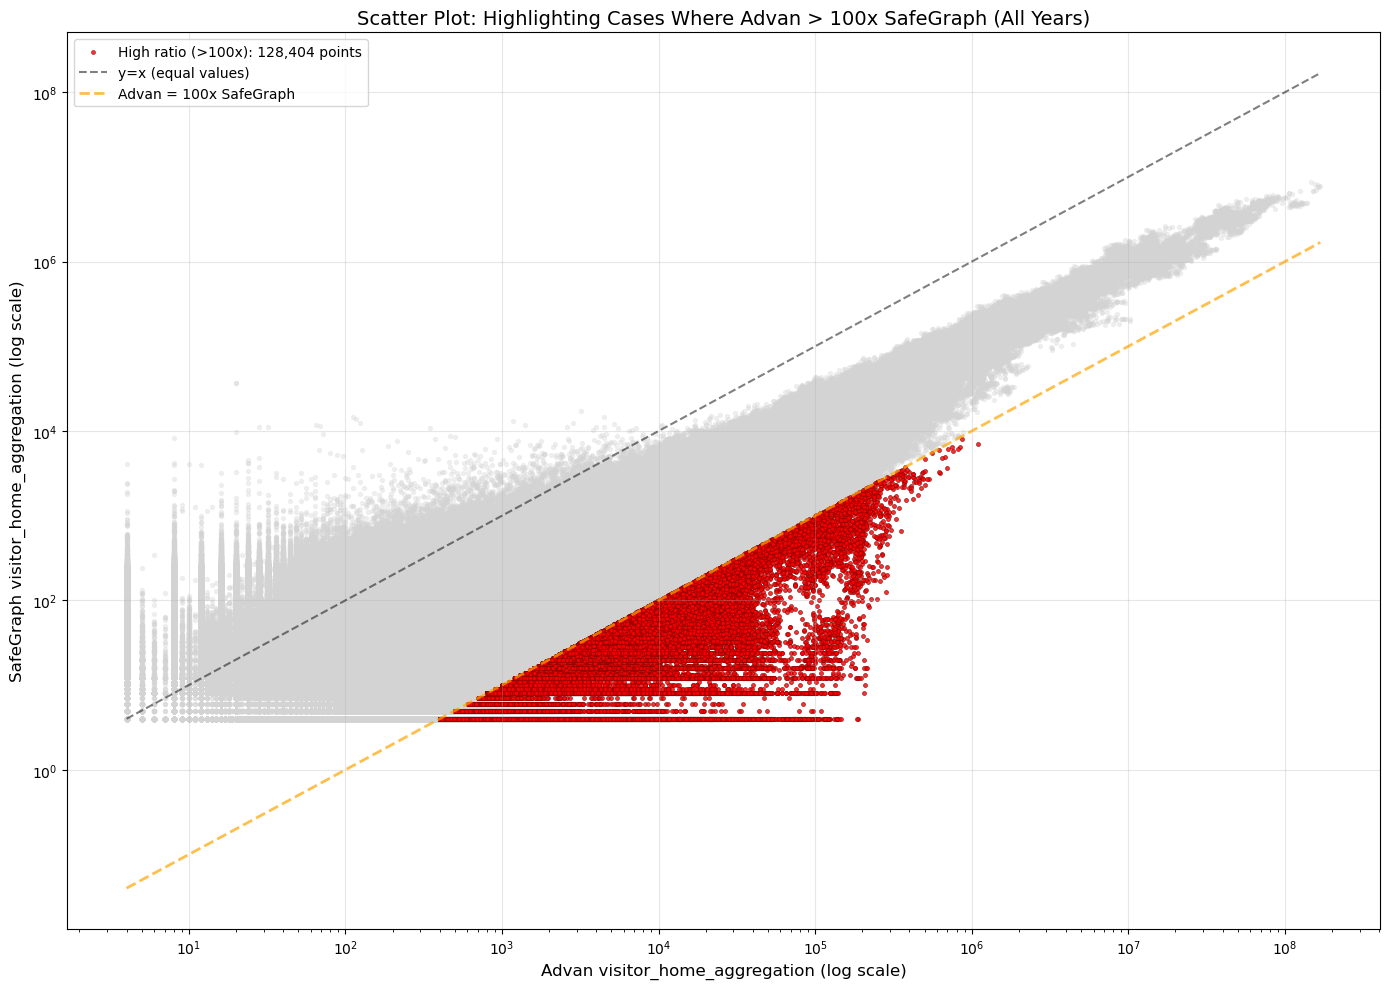


High ratio cases summary:
- Mean ratio: 340.0
- Median ratio: 158.0
- Max ratio: 47038.8


In [66]:
# Scatter plot highlighting high ratio cases
plt.figure(figsize=(14, 10))

# Sample the full dataset for visualization (to avoid overplotting)
sample_size = min(100000, len(merged_df_clean))
merged_sample = merged_df_clean.sample(n=sample_size, random_state=42)

# Plot sampled data points in light gray
plt.scatter(
    merged_df_clean['visitor_home_aggregation_advan'],
    merged_df_clean['visitor_home_aggregation_safegraph'],
    c='lightgray',
    alpha=0.3,
    s=8
)

# Highlight high ratio cases in red
plt.scatter(
    high_ratio_df['visitor_home_aggregation_advan'],
    high_ratio_df['visitor_home_aggregation_safegraph'],
    c='red',
    alpha=0.8,
    s=8,
    edgecolors='darkred',
    linewidths=0.5,
    label=f'High ratio (>100x): {len(high_ratio_df):,} points'
)

plt.xlabel('Advan visitor_home_aggregation (log scale)', fontsize=12)
plt.ylabel('SafeGraph visitor_home_aggregation (log scale)', fontsize=12)
plt.title('Scatter Plot: Highlighting Cases Where Advan > 100x SafeGraph (All Years)', fontsize=14)
plt.grid(True, alpha=0.3)

# Add diagonal reference line
max_val = max(
    merged_df_clean['visitor_home_aggregation_advan'].max(),
    merged_df_clean['visitor_home_aggregation_safegraph'].max()
)
min_val = max(
    min(merged_df_clean['visitor_home_aggregation_advan'].min(), 
        merged_df_clean['visitor_home_aggregation_safegraph'].min()),
    1e-1
)
plt.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label='y=x (equal values)')

# Add 100x line (where Advan = 100 * SafeGraph)
plt.plot([min_val, max_val], [min_val/100, max_val/100], 'orange', linestyle='--', 
         alpha=0.7, linewidth=2, label='Advan = 100x SafeGraph')

plt.xscale('log')
plt.yscale('log')
plt.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

print(f"\nHigh ratio cases summary:")
print(f"- Mean ratio: {high_ratio_df['ratio'].mean():.1f}")
print(f"- Median ratio: {high_ratio_df['ratio'].median():.1f}")
print(f"- Max ratio: {high_ratio_df['ratio'].max():.1f}")


In [67]:
# Add CBSA names and geographic information
print("Sample of CBSA codes in high ratio data:")
print(high_ratio_df[['cbsa_orig', 'cbsa_dest']].head(10))
print(f"\nUnique origin CBSAs in high ratio data: {high_ratio_df['cbsa_orig'].nunique()}")
print(f"Unique destination CBSAs in high ratio data: {high_ratio_df['cbsa_dest'].nunique()}")

# Add CBSA names using the mapping
high_ratio_df['cbsa_orig_name'] = high_ratio_df['cbsa_orig'].map(TITLE_CBSA_MAP)
high_ratio_df['cbsa_dest_name'] = high_ratio_df['cbsa_dest'].map(TITLE_CBSA_MAP)
high_ratio_df['cbsa_pair'] = high_ratio_df['cbsa_orig'] + ' -> ' + high_ratio_df['cbsa_dest']
high_ratio_df['cbsa_pair_names'] = high_ratio_df['cbsa_orig_name'] + ' -> ' + high_ratio_df['cbsa_dest_name']

# Load CBSA to state mapping from the data file
cbsa_state_df = pd.read_csv("../../data/raw/list1_2023.csv", dtype={"CBSA Code": str})
cbsa_state_df = cbsa_state_df.iloc[:-3]  # Remove footer rows

# Create CBSA to state mapping
cbsa_to_state = cbsa_state_df.groupby("CBSA Code")["State Name"].apply(lambda x: ', '.join(sorted(set(x)))).to_dict()

# Add state information
high_ratio_df['orig_states'] = high_ratio_df['cbsa_orig'].map(cbsa_to_state)
high_ratio_df['dest_states'] = high_ratio_df['cbsa_dest'].map(cbsa_to_state)

print(f"\nSuccessfully loaded state mapping for CBSAs")
print(f"Sample state mappings:")
print(high_ratio_df[['cbsa_orig', 'cbsa_orig_name', 'orig_states']].drop_duplicates().head())



Sample of CBSA codes in high ratio data:
    cbsa_orig cbsa_dest
288     10100     11260
358     10100     12580
359     10100     12580
462     10100     13900
464     10100     13900
480     10100     13900
510     10100     13900
512     10100     13900
513     10100     13900
554     10100     13900

Unique origin CBSAs in high ratio data: 917
Unique destination CBSAs in high ratio data: 901

Successfully loaded state mapping for CBSAs
Sample state mappings:
      cbsa_orig cbsa_orig_name   orig_states
288       10100   Aberdeen, SD  South Dakota
6177      10140   Aberdeen, WA    Washington
14399     10180    Abilene, TX         Texas
33504     10220        Ada, OK      Oklahoma
42337     10300     Adrian, MI      Michigan


In [68]:
# Analyze patterns in high ratio cases

# 1. Top CBSA pairs with high ratios (with names)
print("=== TOP 20 CBSA PAIRS WITH HIGHEST RATIOS ===")
top_cbsa_pairs = high_ratio_df.groupby(['cbsa_pair', 'cbsa_pair_names']).agg({
    'ratio': ['count', 'mean', 'median', 'max'],
    'visitor_home_aggregation_advan': 'mean',
    'visitor_home_aggregation_safegraph': 'mean'
}).round(2)

top_cbsa_pairs.columns = ['count', 'mean_ratio', 'median_ratio', 'max_ratio', 'mean_advan', 'mean_safegraph']
top_cbsa_pairs = top_cbsa_pairs.reset_index().sort_values('mean_ratio', ascending=False)

print("Top pairs by mean ratio:")
for i, row in top_cbsa_pairs.head(15).iterrows():
    print(f"{row['cbsa_pair_names']}")
    print(f"  → {row['count']} records, mean ratio: {row['mean_ratio']:.1f}x, max: {row['max_ratio']:.1f}x")
    print()

print(f"Total unique CBSA pairs with high ratios: {len(top_cbsa_pairs)}")


=== TOP 20 CBSA PAIRS WITH HIGHEST RATIOS ===
Top pairs by mean ratio:
Allentown-Bethlehem-Easton, PA-NJ -> Johnson City, TN
  → 86 records, mean ratio: 14037.4x, max: 33031.2x

East Stroudsburg, PA -> Johnson City, TN
  → 22 records, mean ratio: 13558.4x, max: 23306.8x

Harrisburg-Carlisle, PA -> Johnson City, TN
  → 94 records, mean ratio: 12823.9x, max: 30154.5x

Pottsville, PA -> Johnson City, TN
  → 27 records, mean ratio: 11559.6x, max: 18344.2x

Roanoke, VA -> Boone, NC
  → 141 records, mean ratio: 9847.2x, max: 47038.8x

Roanoke, VA -> Waynesville, NC
  → 91 records, mean ratio: 8550.6x, max: 18789.0x

Tupelo, MS -> Natchez, MS-LA
  → 135 records, mean ratio: 7166.9x, max: 24030.0x

Asheville, NC -> Roanoke, VA
  → 151 records, mean ratio: 4820.4x, max: 29433.8x

East Stroudsburg, PA -> Kingsport-Bristol, TN-VA
  → 89 records, mean ratio: 4741.4x, max: 11106.0x

Lynchburg, VA -> Boone, NC
  → 133 records, mean ratio: 4454.4x, max: 16510.0x

East Stroudsburg, PA -> Lebanon-Clare

In [69]:
high_ratio_df.head()

,cbsa_orig,cbsa_dest,date_range_start,date_range_end,visitor_home_aggregation_advan,visitor_home_aggregation_safegraph,VISITS_DAY_0,VISITS_DAY_1,VISITS_DAY_2,VISITS_DAY_3,VISITS_DAY_4,VISITS_DAY_5,VISITS_DAY_6,ratio,cbsa_orig_name,cbsa_dest_name,cbsa_pair,cbsa_pair_names,orig_states,dest_states
288,10100,11260,2022-07-25,2022-08-01,1080,8,12,8,7,12,4,8,20,135.000000,"Aberdeen, SD","Anchorage, AK",10100 -> 11260,"Aberdeen, SD -> Anchorage, AK",South Dakota,Alaska
358,10100,12580,2021-06-14,2021-06-21,3017,20,14827,14565,14001,14550,15770,14287,15276,150.850000,"Aberdeen, SD","Baltimore-Columbia-Towson, MD",10100 -> 12580,"Aberdeen, SD -> Baltimore-Columbia-Towson, MD",South Dakota,Maryland
359,10100,12580,2021-06-21,2021-06-28,4025,13,7307,7088,6754,7031,7505,6985,7317,309.615385,"Aberdeen, SD","Baltimore-Columbia-Towson, MD",10100 -> 12580,"Aberdeen, SD -> Baltimore-Columbia-Towson, MD",South Dakota,Maryland
462,10100,13900,2020-08-24,2020-08-31,5188,28,670,653,811,832,847,762,602,185.285714,"Aberdeen, SD","Bismarck, ND",10100 -> 13900,"Aberdeen, SD -> Bismarck, ND",South Dakota,North Dakota
464,10100,13900,2020-09-07,2020-09-14,4076,33,542,447,417,461,495,585,475,123.515152,"Aberdeen, SD","Bismarck, ND",10100 -> 13900,"Aberdeen, SD -> Bismarck, ND",South Dakota,North Dakota


In [70]:
# 2. Most frequent origin CBSAs in high ratio cases
print("\n=== TOP 20 ORIGIN CBSAs IN HIGH RATIO CASES ===")
origin_analysis = high_ratio_df.groupby(['cbsa_orig', 'cbsa_orig_name', 'orig_states']).agg({
    'ratio': ['count', 'mean', 'median'],
    'cbsa_dest': 'nunique'  # Number of unique destinations
}).round(2)

origin_analysis.columns = ['count', 'mean_ratio', 'median_ratio', 'unique_destinations']
origin_analysis = origin_analysis.reset_index().sort_values('count', ascending=False)

print("Top origin CBSAs by frequency:")
for i, row in origin_analysis.head(15).iterrows():
    print(f"{row['cbsa_orig_name']} ({row['orig_states']})")
    print(f"  → {row['count']} high ratio records to {row['unique_destinations']} destinations")
    print(f"  → Mean ratio: {row['mean_ratio']:.1f}x")
    print()

# 3. Most frequent destination CBSAs in high ratio cases  
print("\n=== TOP 20 DESTINATION CBSAs IN HIGH RATIO CASES ===")
dest_analysis = high_ratio_df.groupby(['cbsa_dest', 'cbsa_dest_name', 'dest_states']).agg({
    'ratio': ['count', 'mean', 'median'],
    'cbsa_orig': 'nunique'  # Number of unique origins
}).round(2)

dest_analysis.columns = ['count', 'mean_ratio', 'median_ratio', 'unique_origins']
dest_analysis = dest_analysis.reset_index().sort_values('count', ascending=False)

print("Top destination CBSAs by frequency:")
for i, row in dest_analysis.head(15).iterrows():
    print(f"{row['cbsa_dest_name']} ({row['dest_states']})")
    print(f"  → {row['count']} high ratio records from {row['unique_origins']} origins")
    print(f"  → Mean ratio: {row['mean_ratio']:.1f}x")
    print()



=== TOP 20 ORIGIN CBSAs IN HIGH RATIO CASES ===
Top origin CBSAs by frequency:
Sevierville, TN (Tennessee)
  → 6897 high ratio records to 348 destinations
  → Mean ratio: 257.9x

Las Vegas-Henderson-North Las Vegas, NV (Nevada)
  → 4478 high ratio records to 441 destinations
  → Mean ratio: 193.5x

New Orleans-Metairie, LA (Louisiana)
  → 3107 high ratio records to 426 destinations
  → Mean ratio: 276.6x

Orlando-Kissimmee-Sanford, FL (Florida)
  → 2796 high ratio records to 487 destinations
  → Mean ratio: 182.0x

Panama City-Panama City Beach, FL (Florida)
  → 1884 high ratio records to 241 destinations
  → Mean ratio: 195.7x

East Stroudsburg, PA (Pennsylvania)
  → 1859 high ratio records to 110 destinations
  → Mean ratio: 1139.9x

Allentown-Bethlehem-Easton, PA-NJ (New Jersey, Pennsylvania)
  → 1786 high ratio records to 68 destinations
  → Mean ratio: 1660.5x

Branson, MO (Missouri)
  → 1331 high ratio records to 180 destinations
  → Mean ratio: 194.8x

Pottsville, PA (Pennsylva

In [71]:
# State-level analysis of high ratio cases
print("\n" + "="*60)
print("STATE-LEVEL ANALYSIS")
print("="*60)

# Function to extract primary state from multi-state strings
def get_primary_state(state_str):
    if pd.isna(state_str) or state_str == 'Unknown':
        return 'Unknown'
    return state_str.split(',')[0].strip()

# Add primary state columns
high_ratio_df['orig_primary_state'] = high_ratio_df['orig_states'].apply(get_primary_state)
high_ratio_df['dest_primary_state'] = high_ratio_df['dest_states'].apply(get_primary_state)

# Origin states analysis
print("\n=== TOP ORIGIN STATES IN HIGH RATIO CASES ===")
origin_state_analysis = high_ratio_df.groupby('orig_primary_state').agg({
    'ratio': ['count', 'mean', 'median'],
    'cbsa_orig': 'nunique',
    'cbsa_dest': 'nunique'
}).round(2)

origin_state_analysis.columns = ['count', 'mean_ratio', 'median_ratio', 'unique_orig_cbsas', 'unique_dest_cbsas']
origin_state_analysis = origin_state_analysis.sort_values('count', ascending=False)

print("Top origin states by high ratio frequency:")
for state, row in origin_state_analysis.head(15).iterrows():
    print(f"{state}: {row['count']} records, mean ratio: {row['mean_ratio']:.1f}x")
    print(f"  → From {row['unique_orig_cbsas']} CBSAs to {row['unique_dest_cbsas']} destination CBSAs")

# Destination states analysis
print("\n=== TOP DESTINATION STATES IN HIGH RATIO CASES ===")
dest_state_analysis = high_ratio_df.groupby('dest_primary_state').agg({
    'ratio': ['count', 'mean', 'median'],
    'cbsa_orig': 'nunique',
    'cbsa_dest': 'nunique'
}).round(2)

dest_state_analysis.columns = ['count', 'mean_ratio', 'median_ratio', 'unique_orig_cbsas', 'unique_dest_cbsas']
dest_state_analysis = dest_state_analysis.sort_values('count', ascending=False)

print("Top destination states by high ratio frequency:")
for state, row in dest_state_analysis.head(15).iterrows():
    print(f"{state}: {row['count']} records, mean ratio: {row['mean_ratio']:.1f}x")
    print(f"  → To {row['unique_dest_cbsas']} CBSAs from {row['unique_orig_cbsas']} origin CBSAs")



STATE-LEVEL ANALYSIS

=== TOP ORIGIN STATES IN HIGH RATIO CASES ===
Top origin states by high ratio frequency:
Pennsylvania: 12609.0 records, mean ratio: 735.4x
  → From 34.0 CBSAs to 376.0 destination CBSAs
Tennessee: 10144.0 records, mean ratio: 240.9x
  → From 24.0 CBSAs to 547.0 destination CBSAs
Florida: 8409.0 records, mean ratio: 184.5x
  → From 28.0 CBSAs to 626.0 destination CBSAs
North Carolina: 6600.0 records, mean ratio: 642.4x
  → From 39.0 CBSAs to 341.0 destination CBSAs
Nevada: 4722.0 records, mean ratio: 192.6x
  → From 7.0 CBSAs to 483.0 destination CBSAs
Louisiana: 4634.0 records, mean ratio: 266.9x
  → From 19.0 CBSAs to 464.0 destination CBSAs
Texas: 4516.0 records, mean ratio: 187.7x
  → From 66.0 CBSAs to 498.0 destination CBSAs
Alabama: 4262.0 records, mean ratio: 260.8x
  → From 26.0 CBSAs to 401.0 destination CBSAs
Mississippi: 4250.0 records, mean ratio: 562.2x
  → From 19.0 CBSAs to 252.0 destination CBSAs
Ohio: 4154.0 records, mean ratio: 189.6x
  → From 4


TEMPORAL PATTERNS IN HIGH RATIO CASES
Yearly distribution:
      count  mean_ratio  median_ratio
year                                 
2020  33990      368.89        161.75
2021  38936      343.03        157.50
2022  55478      320.21        156.00

Monthly distribution:
       count  mean_ratio  median_ratio
month                                 
1       9336      344.37        160.00
2       7911      366.03        161.00
3       8338      370.07        160.25
4       7748      371.89        160.98
5      11019      367.32        160.00
6      10669      346.62        154.50
7      13074      306.42        154.00
8      16931      316.89        157.50
9      11085      326.72        157.42
10     11819      355.15        159.00
11     11923      354.15        159.88
12      8551      283.35        155.00


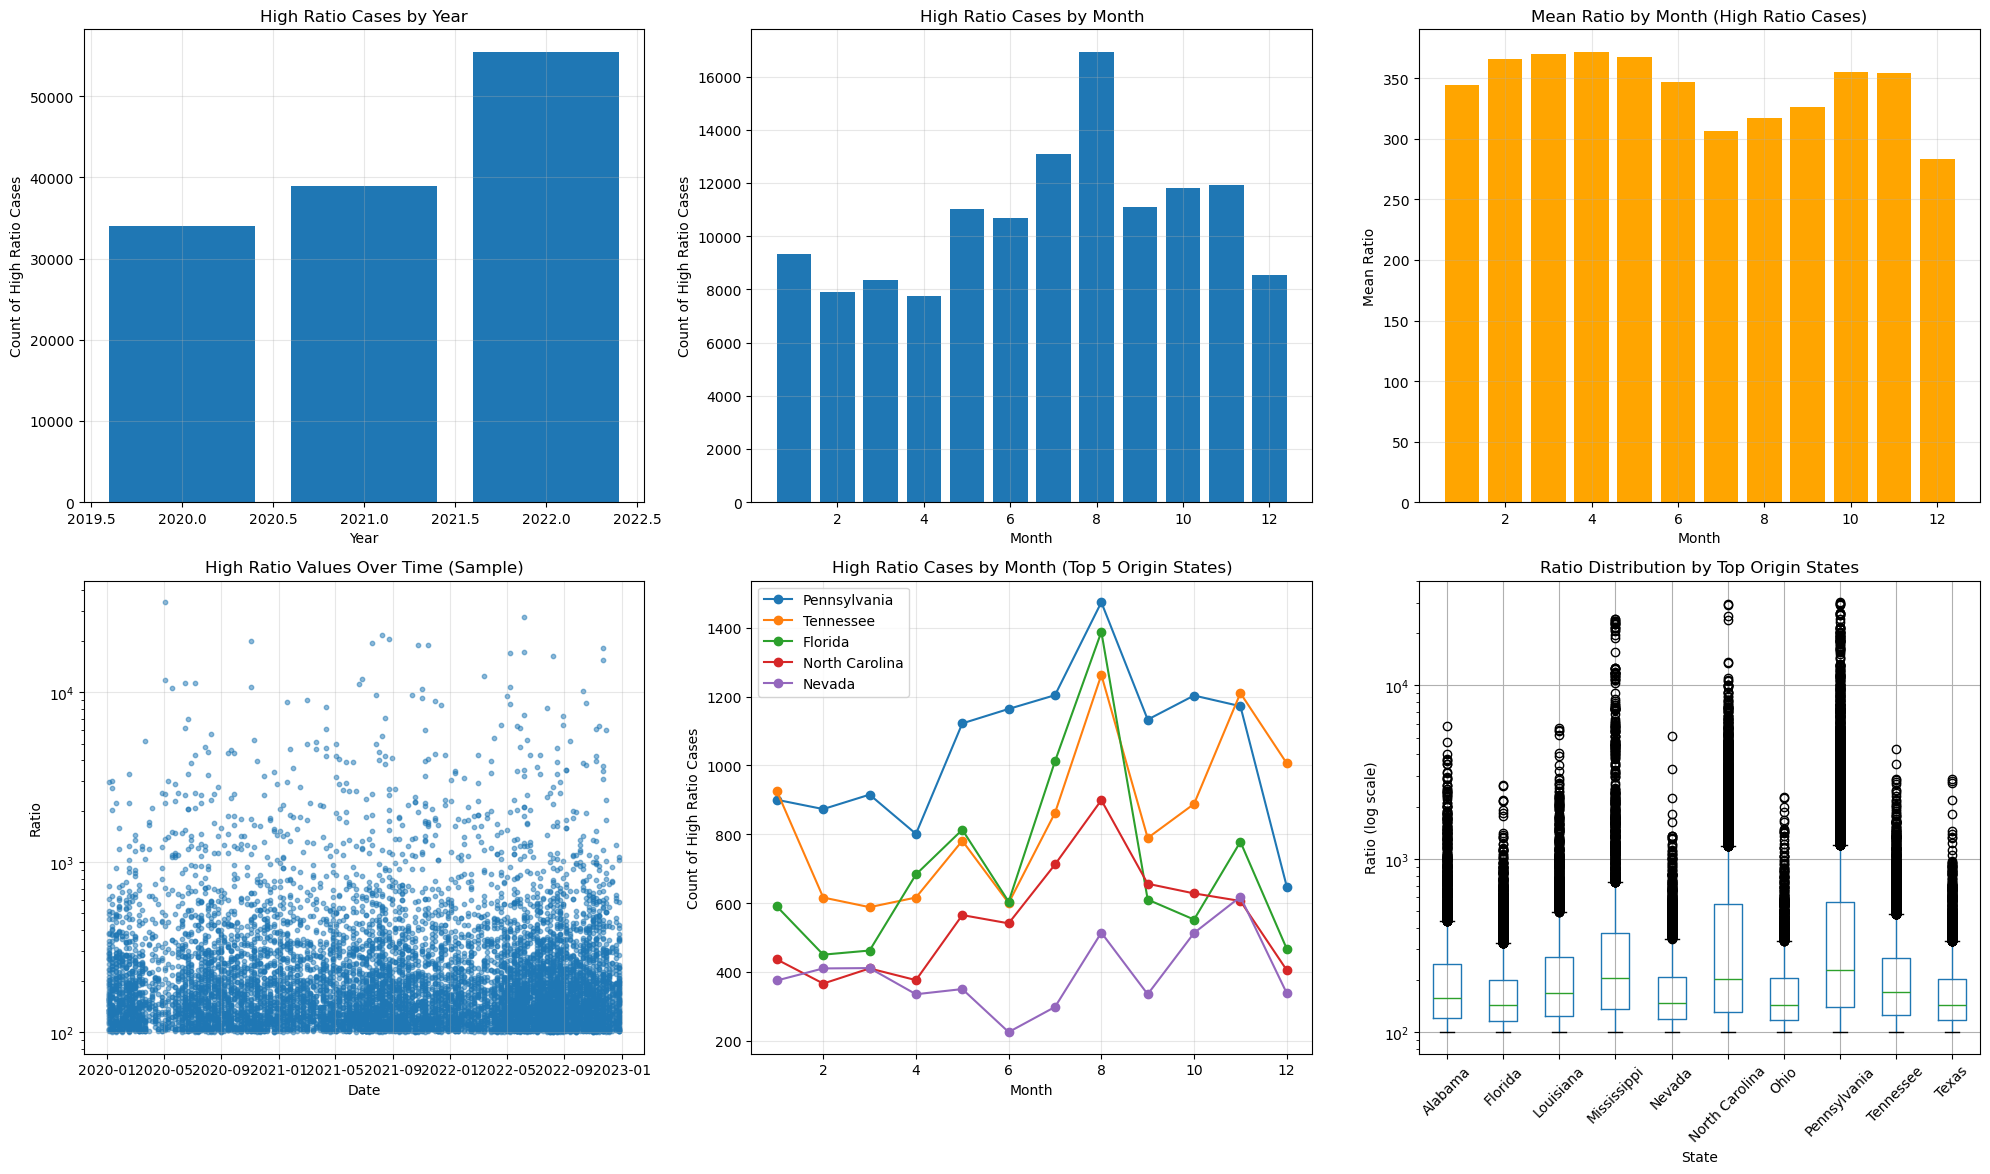

In [72]:
# Temporal patterns in high ratio cases
high_ratio_df['month'] = high_ratio_df['date_range_start'].dt.month
high_ratio_df['year'] = high_ratio_df['date_range_start'].dt.year
high_ratio_df['week'] = high_ratio_df['date_range_start'].dt.isocalendar().week

print("\n" + "="*60)
print("TEMPORAL PATTERNS IN HIGH RATIO CASES")
print("="*60)

# Yearly patterns
yearly_patterns = high_ratio_df.groupby('year').agg({
    'ratio': ['count', 'mean', 'median']
}).round(2)
yearly_patterns.columns = ['count', 'mean_ratio', 'median_ratio']

print("Yearly distribution:")
print(yearly_patterns)

# Monthly patterns
monthly_patterns = high_ratio_df.groupby('month').agg({
    'ratio': ['count', 'mean', 'median']
}).round(2)
monthly_patterns.columns = ['count', 'mean_ratio', 'median_ratio']

print("\nMonthly distribution:")
print(monthly_patterns)

# Plot temporal patterns
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Yearly count
axes[0, 0].bar(yearly_patterns.index, yearly_patterns['count'])
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Count of High Ratio Cases')
axes[0, 0].set_title('High Ratio Cases by Year')
axes[0, 0].grid(True, alpha=0.3)

# Monthly count
axes[0, 1].bar(monthly_patterns.index, monthly_patterns['count'])
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Count of High Ratio Cases')
axes[0, 1].set_title('High Ratio Cases by Month')
axes[0, 1].grid(True, alpha=0.3)

# Monthly mean ratio
axes[0, 2].bar(monthly_patterns.index, monthly_patterns['mean_ratio'], color='orange')
axes[0, 2].set_xlabel('Month')
axes[0, 2].set_ylabel('Mean Ratio')
axes[0, 2].set_title('Mean Ratio by Month (High Ratio Cases)')
axes[0, 2].grid(True, alpha=0.3)

# Ratio distribution over time
sample_high_ratio = high_ratio_df.sample(n=min(10000, len(high_ratio_df)), random_state=42)
axes[1, 0].scatter(sample_high_ratio['date_range_start'], sample_high_ratio['ratio'], 
                   alpha=0.5, s=10)
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Ratio')
axes[1, 0].set_title('High Ratio Values Over Time (Sample)')
axes[1, 0].set_yscale('log')
axes[1, 0].grid(True, alpha=0.3)

# Top states over time
top_5_orig_states = origin_state_analysis.head(5).index
for state in top_5_orig_states:
    if state != 'Unknown':
        state_data = high_ratio_df[high_ratio_df['orig_primary_state'] == state]
        monthly_state = state_data.groupby('month')['ratio'].count()
        axes[1, 1].plot(monthly_state.index, monthly_state.values, marker='o', label=state)

axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Count of High Ratio Cases')
axes[1, 1].set_title('High Ratio Cases by Month (Top 5 Origin States)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# State vs ratio distribution
top_states_data = []
for state in origin_state_analysis.head(10).index:
    if state != 'Unknown':
        state_ratios = high_ratio_df[high_ratio_df['orig_primary_state'] == state]['ratio']
        top_states_data.extend([(state, ratio) for ratio in state_ratios])

if top_states_data:
    state_df = pd.DataFrame(top_states_data, columns=['state', 'ratio'])
    state_df.boxplot(column='ratio', by='state', ax=axes[1, 2])
    axes[1, 2].set_xlabel('State')
    axes[1, 2].set_ylabel('Ratio (log scale)')
    axes[1, 2].set_yscale('log')
    axes[1, 2].set_title('Ratio Distribution by Top Origin States')
    axes[1, 2].tick_params(axis='x', rotation=45)
    plt.suptitle('')  # Remove default title

plt.tight_layout()
plt.show()



=== VISUALIZATION OF TOP HIGH RATIO CBSA PAIRS ===


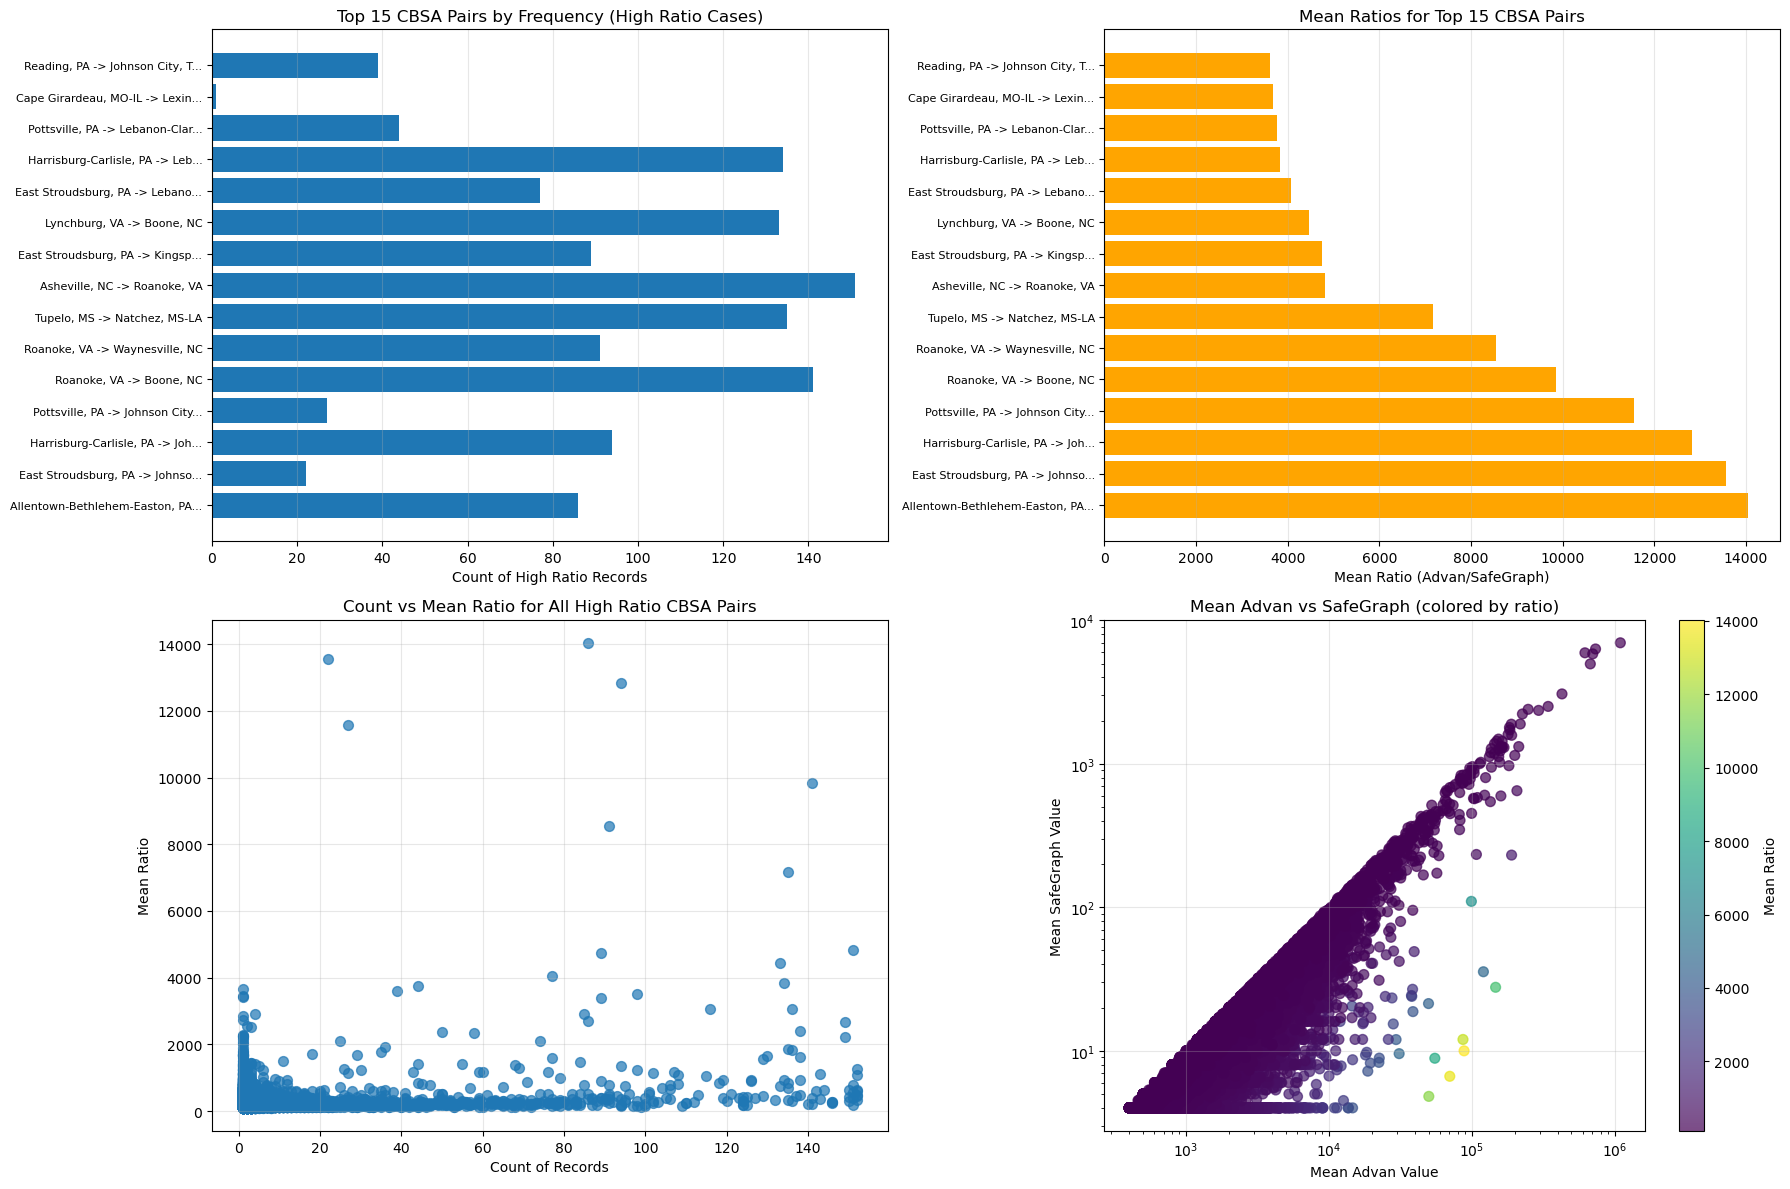

In [73]:
# 5. Visualize top CBSA pairs and their characteristics
print("\n=== VISUALIZATION OF TOP HIGH RATIO CBSA PAIRS ===")

# Get top 15 pairs by frequency
top_15_pairs = top_cbsa_pairs.head(15)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Bar plot of counts for top pairs
pair_names = [pair[:30] + '...' if len(pair) > 30 else pair for pair in top_15_pairs['cbsa_pair_names']]
axes[0, 0].barh(range(len(top_15_pairs)), top_15_pairs['count'])
axes[0, 0].set_yticks(range(len(top_15_pairs)))
axes[0, 0].set_yticklabels(pair_names, fontsize=8)
axes[0, 0].set_xlabel('Count of High Ratio Records')
axes[0, 0].set_title('Top 15 CBSA Pairs by Frequency (High Ratio Cases)')
axes[0, 0].grid(True, alpha=0.3, axis='x')

# Bar plot of mean ratios for top pairs
axes[0, 1].barh(range(len(top_15_pairs)), top_15_pairs['mean_ratio'], color='orange')
axes[0, 1].set_yticks(range(len(top_15_pairs)))
axes[0, 1].set_yticklabels(pair_names, fontsize=8)
axes[0, 1].set_xlabel('Mean Ratio (Advan/SafeGraph)')
axes[0, 1].set_title('Mean Ratios for Top 15 CBSA Pairs')
axes[0, 1].grid(True, alpha=0.3, axis='x')

# Scatter: count vs mean ratio
axes[1, 0].scatter(top_cbsa_pairs['count'], top_cbsa_pairs['mean_ratio'], 
                   alpha=0.7, s=50)
axes[1, 0].set_xlabel('Count of Records')
axes[1, 0].set_ylabel('Mean Ratio')
axes[1, 0].set_title('Count vs Mean Ratio for All High Ratio CBSA Pairs')
axes[1, 0].grid(True, alpha=0.3)

# Distribution of mean Advan vs SafeGraph values for high ratio pairs
axes[1, 1].scatter(top_cbsa_pairs['mean_advan'], top_cbsa_pairs['mean_safegraph'], 
                   alpha=0.7, s=50, c=top_cbsa_pairs['mean_ratio'], 
                   cmap='viridis')
axes[1, 1].set_ylabel('Mean SafeGraph Value')
axes[1, 1].set_xlabel('Mean Advan Value')
axes[1, 1].set_title('Mean Advan vs SafeGraph (colored by ratio)')
axes[1, 1].set_xscale('log')
axes[1, 1].set_yscale('log')
cbar = plt.colorbar(axes[1, 1].collections[0], ax=axes[1, 1])
cbar.set_label('Mean Ratio')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [74]:
# Summary insights and key findings
print("\n" + "="*80)
print("COMPREHENSIVE SUMMARY: HIGH RATIO CASES (ADVAN > 100x SAFEGRAPH)")
print("="*80)

print(f"\n📊 OVERALL STATISTICS:")
print(f"   • Total high ratio records: {len(high_ratio_df):,} ({len(high_ratio_df)/len(merged_df_clean)*100:.3f}% of all data)")
print(f"   • Date range: {high_ratio_df['date_range_start'].min().strftime('%Y-%m-%d')} to {high_ratio_df['date_range_start'].max().strftime('%Y-%m-%d')}")
print(f"   • Years covered: {', '.join(map(str, sorted(high_ratio_df['year'].unique())))}")
print(f"   • Unique CBSA pairs involved: {len(top_cbsa_pairs)}")
print(f"   • Ratio range: {high_ratio_df['ratio'].min():.1f}x to {high_ratio_df['ratio'].max():.1f}x")
print(f"   • Mean ratio: {high_ratio_df['ratio'].mean():.1f}x, Median: {high_ratio_df['ratio'].median():.1f}x")

print(f"\n🎯 TOP PROBLEMATIC CBSA PAIRS:")
for i, row in enumerate(top_cbsa_pairs.head(5).iterrows(), 1):
    _, data = row
    print(f"   {i}. {data['cbsa_pair_names']}")
    print(f"      → {data['count']} records, mean ratio: {data['mean_ratio']:.1f}x")

print(f"\n📍 MOST FREQUENT ORIGIN CBSAs:")
for i, row in enumerate(origin_analysis.head(5).iterrows(), 1):
    _, data = row
    print(f"   {i}. {data['cbsa_orig_name']} ({data['orig_states']})")
    print(f"      → {data['count']} high ratio records to {data['unique_destinations']} destinations")

print(f"\n🎯 MOST FREQUENT DESTINATION CBSAs:")
for i, row in enumerate(dest_analysis.head(5).iterrows(), 1):
    _, data = row
    print(f"   {i}. {data['cbsa_dest_name']} ({data['dest_states']})")
    print(f"      → {data['count']} high ratio records from {data['unique_origins']} origins")

print(f"\n🗺️ STATE-LEVEL PATTERNS:")
print(f"   Top origin states:")
for i, (state, row) in enumerate(origin_state_analysis.head(5).iterrows(), 1):
    print(f"   {i}. {state}: {row['count']} records, mean ratio: {row['mean_ratio']:.1f}x")

print(f"\n   Top destination states:")
for i, (state, row) in enumerate(dest_state_analysis.head(5).iterrows(), 1):
    print(f"   {i}. {state}: {row['count']} records, mean ratio: {row['mean_ratio']:.1f}x")

print(f"\n📅 TEMPORAL PATTERNS:")
peak_year = yearly_patterns['count'].idxmax()
peak_year_count = yearly_patterns['count'].max()
peak_month = monthly_patterns['count'].idxmax()
peak_month_count = monthly_patterns['count'].max()
print(f"   • Peak year: {peak_year} with {peak_year_count:,} high ratio cases")
print(f"   • Peak month: {peak_month} with {peak_month_count:,} high ratio cases")
print(f"   • Most consistent high ratios in month: {monthly_patterns['mean_ratio'].idxmax()}")

print(f"\n🔍 KEY INSIGHTS:")
print(f"   • High ratio cases represent {len(high_ratio_df)/len(merged_df_clean)*100:.3f}% of all mobility records")
print(f"   • Concentrated in specific CBSA pairs, suggesting systematic data differences")
print(f"   • Geographic clustering: certain states consistently appear as origins/destinations")
print(f"   • Temporal variation: clear patterns across years and months")
print(f"   • Potential data quality issues: extreme ratios (up to {high_ratio_df['ratio'].max():.0f}x) suggest")
print(f"     methodological differences between Advan and SafeGraph data collection")

print(f"\n⚠️  RECOMMENDATIONS:")
print(f"   • Investigate data collection methodologies for top problematic CBSA pairs")
print(f"   • Consider separate analysis/modeling for high-discrepancy regions")
print(f"   • Examine temporal patterns to understand if discrepancies are systematic")
print(f"   • Validate findings with domain experts familiar with mobility data sources")

print("\n" + "="*80)



COMPREHENSIVE SUMMARY: HIGH RATIO CASES (ADVAN > 100x SAFEGRAPH)

📊 OVERALL STATISTICS:
   • Total high ratio records: 128,404 (0.921% of all data)
   • Date range: 2020-01-06 to 2022-12-26
   • Years covered: 2020, 2021, 2022
   • Unique CBSA pairs involved: 46425
   • Ratio range: 100.0x to 47038.8x
   • Mean ratio: 340.0x, Median: 158.0x

🎯 TOP PROBLEMATIC CBSA PAIRS:
   1. Allentown-Bethlehem-Easton, PA-NJ -> Johnson City, TN
      → 86 records, mean ratio: 14037.4x
   2. East Stroudsburg, PA -> Johnson City, TN
      → 22 records, mean ratio: 13558.4x
   3. Harrisburg-Carlisle, PA -> Johnson City, TN
      → 94 records, mean ratio: 12823.9x
   4. Pottsville, PA -> Johnson City, TN
      → 27 records, mean ratio: 11559.6x
   5. Roanoke, VA -> Boone, NC
      → 141 records, mean ratio: 9847.2x

📍 MOST FREQUENT ORIGIN CBSAs:
   1. Sevierville, TN (Tennessee)
      → 6897 high ratio records to 348 destinations
   2. Las Vegas-Henderson-North Las Vegas, NV (Nevada)
      → 4478 high r

In [75]:
top_cbsa_pairs

,cbsa_pair,cbsa_pair_names,count,mean_ratio,median_ratio,max_ratio,mean_advan,mean_safegraph
989,10900 -> 27740,"Allentown-Bethlehem-Easton, PA-NJ -> Johnson C...",86,14037.41,14902.88,33031.25,88596.45,9.99
11996,20700 -> 27740,"East Stroudsburg, PA -> Johnson City, TN",22,13558.38,15867.00,23306.75,70381.59,6.64
16837,25420 -> 27740,"Harrisburg-Carlisle, PA -> Johnson City, TN",94,12823.92,10481.62,30154.50,87052.09,11.99
33828,39060 -> 27740,"Pottsville, PA -> Johnson City, TN",27,11559.65,11659.50,18344.25,50207.22,4.81
35238,40220 -> 14380,"Roanoke, VA -> Boone, NC",141,9847.19,6864.85,47038.75,147252.33,27.70
...,...,...,...,...,...,...,...,...
39100,43060 -> 25900,"Shawnee, OK -> Hilo-Kailua, HI",1,100.15,100.15,100.15,5208.00,52.00
3065,12700 -> 31700,"Barnstable Town, MA -> Manchester-Nashua, NH",1,100.14,100.14,100.14,8712.00,87.00
36991,41620 -> 41500,"Salt Lake City-Murray, UT -> Salinas, CA",1,100.14,100.14,100.14,2904.00,29.00
43384,46660 -> 20260,"Valdosta, GA -> Duluth, MN-WI",1,100.12,100.12,100.12,3204.00,32.00


In [76]:
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

merged_df_clean.loc[(merged_df_clean['cbsa_dest'] == '27740') & (merged_df_clean['cbsa_orig'] == '10900')].sort_values('ratio', ascending=False)

,cbsa_orig,cbsa_dest,date_range_start,date_range_end,visitor_home_aggregation_advan,visitor_home_aggregation_safegraph,VISITS_DAY_0,VISITS_DAY_1,VISITS_DAY_2,VISITS_DAY_3,VISITS_DAY_4,VISITS_DAY_5,VISITS_DAY_6,ratio
261058,10900,27740,2022-10-03,2022-10-10,132125,4,0,3,2,5,37,43,0,33031.250000
261059,10900,27740,2022-10-17,2022-10-24,124586,4,17,19,17,26,24,21,19,31146.500000
261060,10900,27740,2022-10-31,2022-11-07,122522,4,8,16,17,16,26,22,17,30630.500000
261054,10900,27740,2022-08-22,2022-08-29,121976,4,9,9,7,12,13,13,11,30494.000000
261062,10900,27740,2022-11-14,2022-11-21,114163,4,4,6,5,10,8,4,2,28540.750000
261044,10900,27740,2022-06-06,2022-06-13,110370,4,3,12,11,11,9,7,13,27592.500000
261040,10900,27740,2022-04-18,2022-04-25,101781,4,0,9,8,19,17,43,13,25445.250000
261045,10900,27740,2022-06-13,2022-06-20,95814,4,31,25,33,39,17,0,0,23953.500000
261025,10900,27740,2021-09-06,2021-09-13,89973,4,92,72,70,84,100,98,71,22493.250000
261022,10900,27740,2021-08-09,2021-08-16,87464,4,84,81,82,86,96,69,85,21866.000000


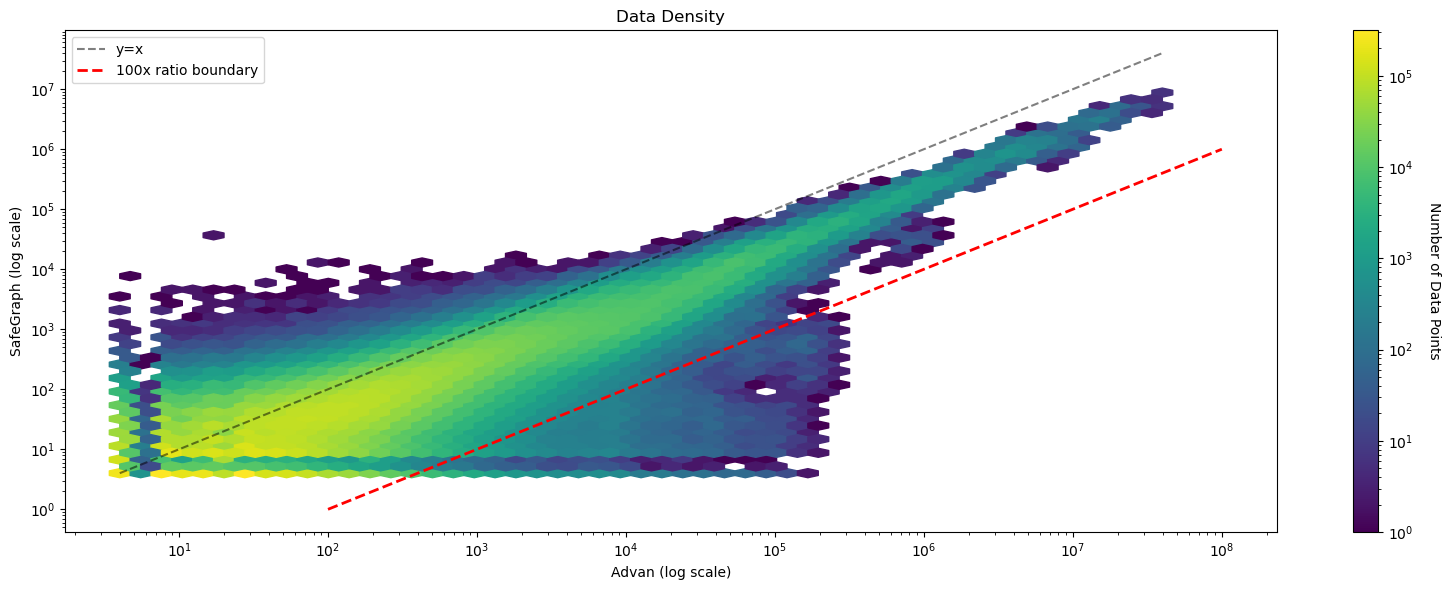

In [41]:
from matplotlib.colors import LogNorm

# Density plot with highlighted high ratio region
fig, ax = plt.subplots(figsize=(16, 6))



hb = ax.hexbin(merged_df_clean['visitor_home_aggregation_advan'], 
               merged_df_clean['visitor_home_aggregation_safegraph'],
               gridsize=50, cmap='viridis', mincnt=1, xscale='log', yscale='log',
               norm=LogNorm())

cb = plt.colorbar(hb, ax=ax)
cb.set_label('Number of Data Points', rotation=270, labelpad=20)

ax.set_xlabel('Advan (log scale)')
ax.set_ylabel('SafeGraph (log scale)')
ax.set_title('Data Density')


max_val = max(
    merged_df_clean['visitor_home_aggregation_advan'].max(),
    merged_df_clean['visitor_home_aggregation_safegraph'].max()
)
min_val = min(
    merged_df_clean['visitor_home_aggregation_advan'].min(),
    merged_df_clean['visitor_home_aggregation_safegraph'].min()
)
plt.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label='y=x')

#Add high ratio boundary line
x_vals = np.logspace(2, 8, 100)
ax.plot(x_vals, x_vals/100, 'r--', linewidth=2, label='100x ratio boundary')
ax.legend()


plt.tight_layout()
plt.show()

## 3. Density plots by population

In [20]:
fields = [
    "SUMLEV",
    "REGION",
    "DIVISION",
    "STATE",
    "COUNTY",
    "STNAME",
    "CTYNAME",
    "POPESTIMATE2021",
    "POPESTIMATE2022",
]
converters = {
    col: str
    for col in [
        "SUMLEV",
        "REGION",
        "DIVISION",
        "STATE",
        "COUNTY",
        "STNAME",
        "CTYNAME",
    ]
}
# Try to use local file first, fallback to URL
local_pop_file = (
    "/burg/apam/users/nhw2114/repos/cgnn/data/raw/co-est2023-alldata.csv"
)
pop_df = pd.read_csv(
    local_pop_file,
    usecols=fields,
    converters=converters,
    encoding="ISO-8859-1",
)

pop_df = pop_df.loc[pop_df["SUMLEV"] == "050"]
pop_df["FIPS"] = pop_df["STATE"] + pop_df["COUNTY"]

# fix connecticut
# https://developer.ap.org/ap-elections-api/docs/CT_FIPS_Codes_forPlanningRegions.htm
ct_fips_mapping = {
    "09190": "09001",
    "09110": "09003",
    "09190": "09005",
    "09130": "09007",
    "09140": "09009",
    "09180": "09011",
    "09110": "09013",
    "09150": "09015",
    "09120": "09001",
    "09160": "09005",
    "09170": "09009",
}
pop_df = pop_df.replace({"FIPS": ct_fips_mapping})
pop_df = pop_df.groupby("FIPS")["POPESTIMATE2021"].sum().reset_index()

assert pop_df.FIPS.nunique() == pop_df.shape[0]

pop_df.head()


,FIPS,POPESTIMATE2021
0,01001,59203
1,01003,239439
2,01005,24533
3,01007,22359
4,01009,59079


In [21]:
# Merge population data with county-to-CBSA mapping and aggregate by CBSA
county_cbsa_map = get_county_cbsa_map()

# Merge population data with CBSA mapping
# Note: FIPS in pop_df corresponds to COUNTY in county_cbsa_map
pop_cbsa_df = pop_df.merge(
    county_cbsa_map,
    left_on="FIPS",
    right_on="COUNTY",
    how="inner"
)

# Aggregate population by CBSA
pop_cbsa_agg = pop_cbsa_df.groupby("CBSA")["POPESTIMATE2021"].sum().reset_index()
pop_cbsa_agg.columns = ["CBSA", "POPULATION"]

print(f"Number of counties: {pop_df.shape[0]}")
print(f"Number of CBSAs with population data: {pop_cbsa_agg.shape[0]}")
print(f"\nTotal population aggregated: {pop_cbsa_agg['POPULATION'].sum():,}")

pop_cbsa_agg.head()


unique ZIPs in zip-cbsa map: 39502
unique ZIPs in zip-county map: 39490
num zips in cbsa but not county: 15
num zips in county but not cbsa: 3
Number of counties: 3142
Number of CBSAs with population data: 919

Total population aggregated: 328,420,398


,CBSA,POPULATION
0,10100,42151
1,10140,76838
2,10180,177831
3,10220,38184
4,10300,99100


In [22]:
merged_df_clean.head()

,cbsa_orig,cbsa_dest,date_range_start,date_range_end,visitor_home_aggregation_advan,visitor_home_aggregation_safegraph,VISITS_DAY_0,VISITS_DAY_1,VISITS_DAY_2,VISITS_DAY_3,VISITS_DAY_4,VISITS_DAY_5,VISITS_DAY_6,ratio
0,10100,10100,2020-01-06,2020-01-13,151812,11375,27851,27190,27663,29677,31863,28565,21748,13.346110
1,10100,10100,2020-01-13,2020-01-20,131991,10190,27430,26734,27750,30045,22002,19180,20930,12.952993
2,10100,10100,2020-01-20,2020-01-27,147445,10735,30615,27835,32040,30700,30243,23449,17518,13.734979
3,10100,10100,2020-01-27,2020-02-03,140151,14009,28956,29462,32772,33208,38168,36296,27762,10.004354
4,10100,10100,2020-02-03,2020-02-10,155653,12048,30658,25661,25611,30231,31424,32261,21554,12.919406


In [23]:
len(set(pop_cbsa_agg['CBSA']) - set(merged_df_clean['cbsa_dest']))

1

In [24]:
# Merge population data to merged_df_clean for both orig and dest CBSAs
# Merge population for origin CBSA
merged_df_clean = merged_df_clean.merge(
    pop_cbsa_agg,
    left_on="cbsa_orig",
    right_on="CBSA",
    how="left",
    suffixes=("", "_orig")
)
merged_df_clean = merged_df_clean.rename(columns={"POPULATION": "orig_pop"})
merged_df_clean = merged_df_clean.drop(columns=["CBSA"])

# Merge population for destination CBSA
merged_df_clean = merged_df_clean.merge(
    pop_cbsa_agg,
    left_on="cbsa_dest",
    right_on="CBSA",
    how="left",
    suffixes=("", "_dest")
)
merged_df_clean = merged_df_clean.rename(columns={"POPULATION": "dest_pop"})
merged_df_clean = merged_df_clean.drop(columns=["CBSA"])

print(f"Records with orig_pop: {merged_df_clean['orig_pop'].notna().sum():,}")
print(f"Records with dest_pop: {merged_df_clean['dest_pop'].notna().sum():,}")
print(f"Total records: {len(merged_df_clean):,}")

merged_df_clean.head()


Records with orig_pop: 13,941,562
Records with dest_pop: 13,934,368
Total records: 13,941,562


,cbsa_orig,cbsa_dest,date_range_start,date_range_end,visitor_home_aggregation_advan,visitor_home_aggregation_safegraph,VISITS_DAY_0,VISITS_DAY_1,VISITS_DAY_2,VISITS_DAY_3,VISITS_DAY_4,VISITS_DAY_5,VISITS_DAY_6,ratio,orig_pop,dest_pop
0,10100,10100,2020-01-06,2020-01-13,151812,11375,27851,27190,27663,29677,31863,28565,21748,13.346110,42151,42151.0
1,10100,10100,2020-01-13,2020-01-20,131991,10190,27430,26734,27750,30045,22002,19180,20930,12.952993,42151,42151.0
2,10100,10100,2020-01-20,2020-01-27,147445,10735,30615,27835,32040,30700,30243,23449,17518,13.734979,42151,42151.0
3,10100,10100,2020-01-27,2020-02-03,140151,14009,28956,29462,32772,33208,38168,36296,27762,10.004354,42151,42151.0
4,10100,10100,2020-02-03,2020-02-10,155653,12048,30658,25661,25611,30231,31424,32261,21554,12.919406,42151,42151.0


In [29]:
# Create density plots of visitor_home_aggregation divided by population
# Filter out rows with missing population data
plot_df = merged_df_clean[
    merged_df_clean['orig_pop'].notna() & 
    merged_df_clean['dest_pop'].notna()
].copy()

# Calculate normalized values
plot_df['advan_per_orig_pop'] = plot_df['visitor_home_aggregation_advan'] / plot_df['orig_pop']
plot_df['safegraph_per_orig_pop'] = plot_df['visitor_home_aggregation_safegraph'] / plot_df['orig_pop']
plot_df['advan_per_dest_pop'] = plot_df['visitor_home_aggregation_advan'] / plot_df['dest_pop']
plot_df['safegraph_per_dest_pop'] = plot_df['visitor_home_aggregation_safegraph'] / plot_df['dest_pop']

# Filter out zeros and extreme outliers for better visualization
# Remove zeros from all columns
plot_df = plot_df[
    (plot_df['advan_per_orig_pop'] > 0) & 
    (plot_df['safegraph_per_orig_pop'] > 0) &
    (plot_df['advan_per_dest_pop'] > 0) &
    (plot_df['safegraph_per_dest_pop'] > 0)
]

# Filter extreme outliers (top 0.1%) to focus on the main distribution
# Calculate all thresholds first, then filter once
thresholds = {}
for col in ['advan_per_orig_pop', 'safegraph_per_orig_pop', 'advan_per_dest_pop', 'safegraph_per_dest_pop']:
    thresholds[col] = plot_df[col].quantile(0.999)  # 99.9th percentile

# Apply all filters at once
# plot_df = plot_df[
#     (plot_df['advan_per_orig_pop'] <= thresholds['advan_per_orig_pop']) &
#     (plot_df['safegraph_per_orig_pop'] <= thresholds['safegraph_per_orig_pop']) &
#     (plot_df['advan_per_dest_pop'] <= thresholds['advan_per_dest_pop']) &
#     (plot_df['safegraph_per_dest_pop'] <= thresholds['safegraph_per_dest_pop'])
# ]

In [30]:
thresholds

{'advan_per_orig_pop': 4.5748052114757884,
 'safegraph_per_orig_pop': 0.5087515757591348,
 'advan_per_dest_pop': 4.448620871961574,
 'safegraph_per_dest_pop': 0.5087515757591348}

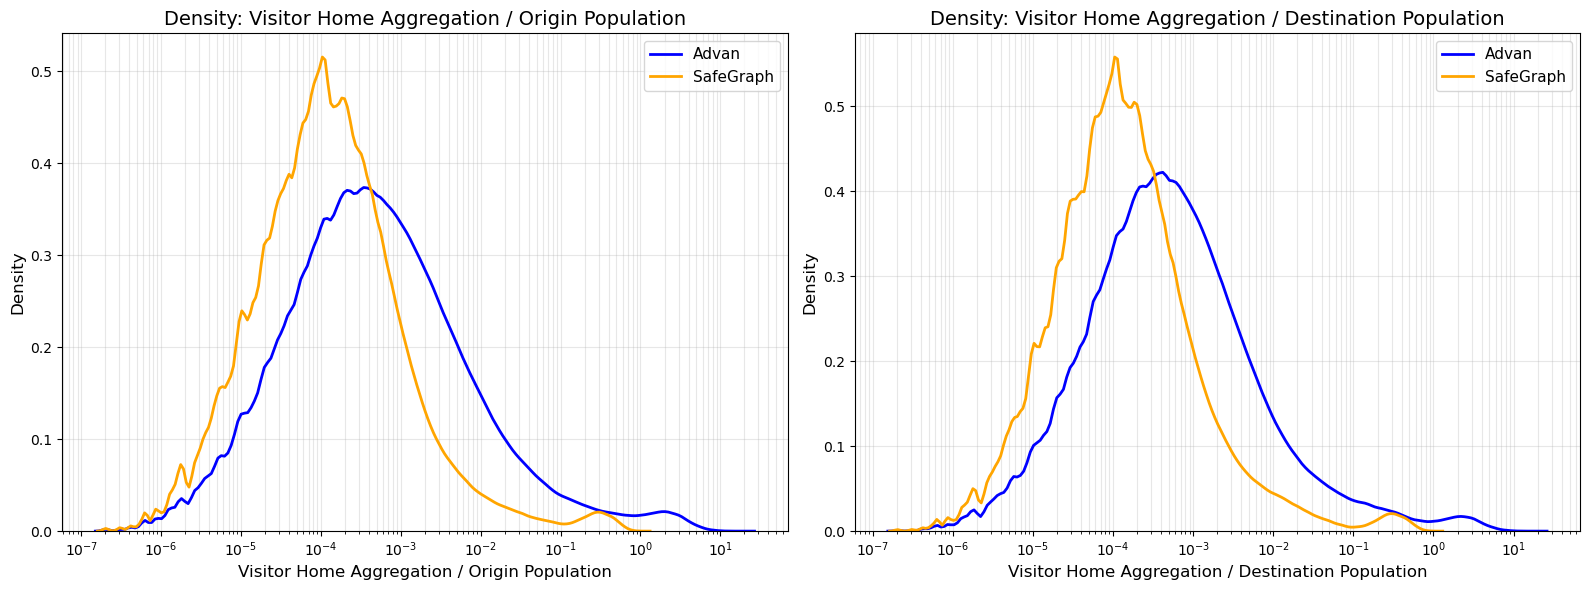

Number of records used for plotting: 13,934,368

Summary Statistics (after filtering):

Origin Population Ratios:
  Advan - Median: 0.000415, Mean: 0.043037
  SafeGraph - Median: 0.000114, Mean: 0.004471

Destination Population Ratios:
  Advan - Median: 0.000447, Mean: 0.036529
  SafeGraph - Median: 0.000117, Mean: 0.004278


In [31]:
# Create figure with two subplots using KDE for smoother density curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left subplot: divided by orig pop
# Transform to log space first for proper density calculation, then plot on log scale
sns.kdeplot(data=plot_df, x='advan_per_orig_pop', ax=ax1, label='Advan', color='blue', 
            linewidth=2, fill=False, log_scale=True, warn_singular=False)
sns.kdeplot(data=plot_df, x='safegraph_per_orig_pop', ax=ax1, label='SafeGraph', color='orange', 
            linewidth=2, fill=False, log_scale=True, warn_singular=False)
ax1.set_xlabel('Visitor Home Aggregation / Origin Population', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.set_title('Density: Visitor Home Aggregation / Origin Population', fontsize=14)
ax1.set_ylim(bottom=0)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3, which='both')

# Right subplot: divided by dest pop
sns.kdeplot(data=plot_df, x='advan_per_dest_pop', ax=ax2, label='Advan', color='blue', 
            linewidth=2, fill=False, log_scale=True, warn_singular=False)
sns.kdeplot(data=plot_df, x='safegraph_per_dest_pop', ax=ax2, label='SafeGraph', color='orange', 
            linewidth=2, fill=False, log_scale=True, warn_singular=False)
ax2.set_xlabel('Visitor Home Aggregation / Destination Population', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.set_title('Density: Visitor Home Aggregation / Destination Population', fontsize=14)
ax2.set_ylim(bottom=0)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"Number of records used for plotting: {len(plot_df):,}")
print("\nSummary Statistics (after filtering):")
print("\nOrigin Population Ratios:")
print(f"  Advan - Median: {plot_df['advan_per_orig_pop'].median():.6f}, Mean: {plot_df['advan_per_orig_pop'].mean():.6f}")
print(f"  SafeGraph - Median: {plot_df['safegraph_per_orig_pop'].median():.6f}, Mean: {plot_df['safegraph_per_orig_pop'].mean():.6f}")
print("\nDestination Population Ratios:")
print(f"  Advan - Median: {plot_df['advan_per_dest_pop'].median():.6f}, Mean: {plot_df['advan_per_dest_pop'].mean():.6f}")
print(f"  SafeGraph - Median: {plot_df['safegraph_per_dest_pop'].median():.6f}, Mean: {plot_df['safegraph_per_dest_pop'].mean():.6f}")


In [42]:
sum(plot_df['safegraph_per_orig_pop'] > 1) / len(plot_df) * 100

6.45885051980829e-05

In [32]:
print(plot_df['advan_per_orig_pop'].max())
print(plot_df['safegraph_per_orig_pop'].max())
print(plot_df['advan_per_dest_pop'].max())
print(plot_df['safegraph_per_dest_pop'].max())

19.847510544113007
1.0369857890800298
19.847510544113007
1.0369857890800298
